# A Hybrid Cost Sensitive Ensemble Approach for Indonesian Local Script Handwritten Recognition 
**Pipeline:** `Data Loading → EDA → Preprocessing → Frozen CNN Features → PCA → Class Weights → Optuna Tuning → XGBoost / LightGBM / CatBoost → Evaluation`

**Target runtime:** Kaggle Notebook (T4 GPU) — also runs on Colab T4 or local CPU/MPS.

## 0. Environment Setup

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_KAGGLE = Path('/kaggle/input').exists()
IN_COLAB  = 'google.colab' in sys.modules

REQUIRED = ['optuna', 'catboost', 'lightgbm', 'xgboost']
missing = []
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        missing.append(pkg)
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

print(f'Environment : {"Kaggle" if IN_KAGGLE else "Colab" if IN_COLAB else "Local"}')
print('Packages OK.')

Environment : Kaggle
Packages OK.


In [2]:
import time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'PyTorch     : {torch.__version__}')
print(f'CUDA avail  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')

PyTorch     : 2.10.0+cu128
CUDA avail  : True
GPU         : Tesla T4


In [3]:
# Resolve dataset root across Kaggle / Colab / local
DATASET_ROOT = None
_candidates = [
    Path('/kaggle/input/datasets/fadhlannurrachman/datasetscript/datasetscript'),   # dataset name: nusantara-script
    Path('/kaggle/input/nusantara-script'),
    Path('/kaggle/input/datasetscript/datasetscript'),       # alternative upload name
    Path('/kaggle/input/datasetscript'),
    Path('/content/datasetscript'),
    Path('/content/drive/MyDrive/datasetscript'),
    Path('./datasetscript'),
    Path('../datasetscript'),
]
for _c in _candidates:
    if _c.exists() and (_c / 'Bali').exists():
        DATASET_ROOT = _c
        break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        'datasetscript/ not found. Tried:\n' + '\n'.join(f'  {p}' for p in _candidates)
    )

WORK_DIR     = Path('/kaggle/working') if IN_KAGGLE else Path('.')
OUTPUT_DIR   = WORK_DIR / 'models'
FEATURES_DIR = WORK_DIR / 'features'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = (
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cpu')
)
N_GPUS        = torch.cuda.device_count() if DEVICE.type == 'cuda' else 0
USE_GPU_TREES = DEVICE.type == 'cuda'
CAT_DEVICES   = ':'.join(str(i) for i in range(N_GPUS)) if N_GPUS > 0 else None

# Hyperparameters
IMG_SIZE         = 224
BATCH_SIZE       = 128 if DEVICE.type == 'cuda' else 64
NUM_WORKERS      = 0
RANDOM_STATE     = 42
TEST_SIZE        = 0.20
PCA_COMPONENTS   = 256
OPTUNA_TRIALS    = 20
TUNE_SUBSAMPLE   = 0.30
FINAL_ESTIMATORS = 500   # XGB/CatBoost on GPU — fast
LGBM_ESTIMATORS  = 100   # LightGBM CPU: 228 classes × 100 rounds ≈ 8 min

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp'}
PALETTE       = sns.color_palette('tab10', n_colors=9)

SCRIPT_CONFIGS = {
    'Bali'   : ['Bali'],
    'Batak'  : ['Batak'],
    'Jawa'   : ['Jawa'],
    'Jawi'   : ['Jawi'],
    'Kawi'   : ['Kawi'],
    'Lampung': ['Lampung'],
    'Lontara': ['Lontara'],
    'Pallawa': ['Pallawa'],
    'Sunda'  : ['Sunda'],
}

print(f'Dataset root : {DATASET_ROOT}')
print(f'Working dir  : {WORK_DIR}')
print(f'Device       : {DEVICE}  |  GPUs: {N_GPUS}  (GPU trees: {USE_GPU_TREES}  CatBoost devices: {CAT_DEVICES})')
print(f'Batch size   : {BATCH_SIZE}  |  workers: {NUM_WORKERS}')
print(f'Estimators   : XGB/CAT={FINAL_ESTIMATORS}  LGBM={LGBM_ESTIMATORS}')
print(f'Optuna trials: {OPTUNA_TRIALS}/model')


Dataset root : /kaggle/input/datasets/fadhlannurrachman/datasetscript/datasetscript
Working dir  : /kaggle/working
Device       : cuda  |  GPUs: 2  (GPU trees: True  CatBoost devices: 0:1)
Batch size   : 128  |  workers: 0
Estimators   : XGB/CAT=500  LGBM=100
Optuna trials: 20/model


## 1. Data Loading & EDA

In [4]:
def load_dataset(root: Path, configs: dict) -> pd.DataFrame:
    records = []
    for script, paths in configs.items():
        for rel in paths:
            script_dir = root / rel
            if not script_dir.exists():
                print(f'  WARNING: {script_dir} missing — skipped')
                continue
            for cls_dir in sorted(script_dir.iterdir()):
                if not cls_dir.is_dir() or cls_dir.name.startswith('.'):
                    continue
                label = f'{script}_{cls_dir.name}'
                for img in cls_dir.iterdir():
                    if img.suffix.lower() in VALID_EXTS:
                        records.append({
                            'filepath': str(img),
                            'label'   : label,
                            'script'  : script,
                            'class'   : cls_dir.name,
                        })
    return pd.DataFrame(records)

t0 = time.time()
df = load_dataset(DATASET_ROOT, SCRIPT_CONFIGS)
print(f'Loaded {len(df):,} images in {time.time()-t0:.1f}s')
print(f'Scripts : {df["script"].nunique()}   |   Classes : {df["label"].nunique()}')
df.head()

Loaded 55,713 images in 3.0s
Scripts : 9   |   Classes : 228


,filepath,label,script,class
0,/kaggle/input/datasets/fadhlannurrachman/datas...,Bali_ba,Bali,ba
1,/kaggle/input/datasets/fadhlannurrachman/datas...,Bali_ba,Bali,ba
2,/kaggle/input/datasets/fadhlannurrachman/datas...,Bali_ba,Bali,ba
3,/kaggle/input/datasets/fadhlannurrachman/datas...,Bali_ba,Bali,ba
4,/kaggle/input/datasets/fadhlannurrachman/datas...,Bali_ba,Bali,ba


In [5]:
# Composition table (mirrors paper Table I)
summary = (
    df.groupby('script')
      .agg(Classes=('label', 'nunique'), Images=('filepath', 'count'))
      .reset_index()
)
summary['Percentage'] = (summary['Images'] / summary['Images'].sum() * 100).round(2)
summary = summary.sort_values('Images', ascending=False).reset_index(drop=True)
total = pd.DataFrame([['Total', summary['Classes'].sum(), summary['Images'].sum(), 100.0]],
                      columns=summary.columns)
print(pd.concat([summary, total], ignore_index=True).to_string(index=False))

cls_counts = df.groupby('label')['filepath'].count()
print(f'\nImbalance ratio (max/min class): {cls_counts.max() / cls_counts.min():.1f}x')

 script  Classes  Images  Percentage
  Sunda       32   20224     36.3000
   Jawa       20    9995     17.9400
   Kawi       31    6246     11.2100
Lampung       20    4996      8.9700
   Bali       18    4493      8.0600
Pallawa       33    3960      7.1100
Lontara       23    2299      4.1300
  Batak       19    1900      3.4100
   Jawi       32    1600      2.8700
  Total      228   55713    100.0000

Imbalance ratio (max/min class): 14.5x


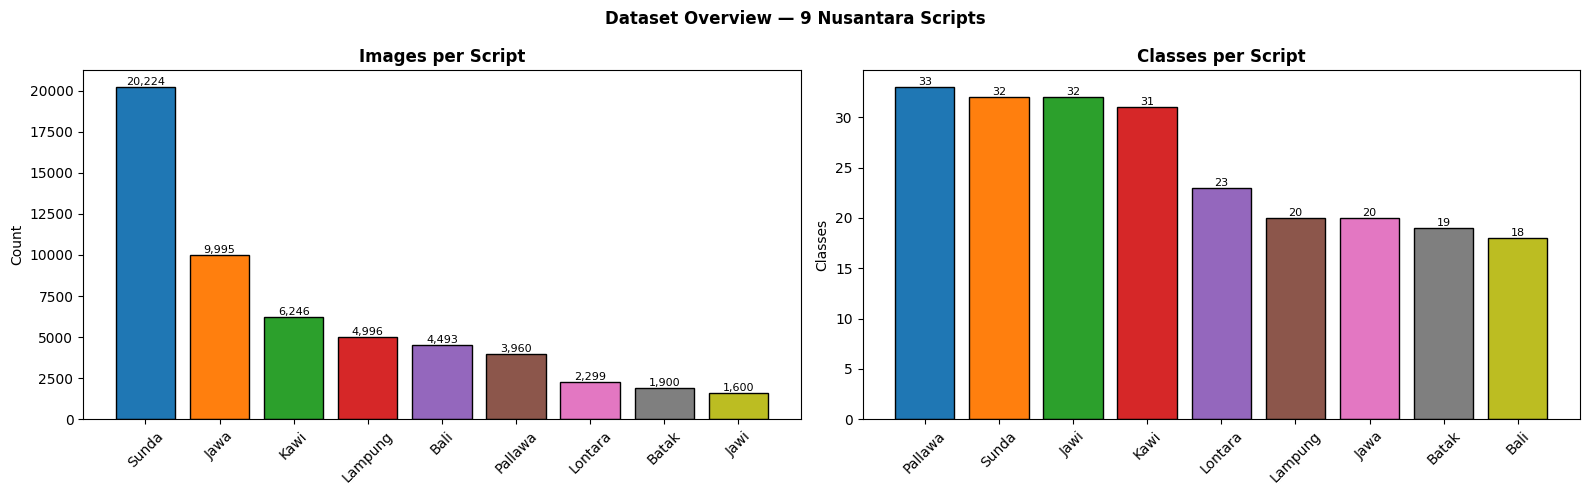

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
img_per_script = df.groupby('script')['filepath'].count().sort_values(ascending=False)
cls_per_script = df.groupby('script')['label'].nunique().sort_values(ascending=False)

for ax, series, title, ylab in [
    (axes[0], img_per_script, 'Images per Script',  'Count'),
    (axes[1], cls_per_script, 'Classes per Script', 'Classes'),
]:
    bars = ax.bar(series.index, series.values, color=PALETTE, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylab)
    ax.tick_params(axis='x', rotation=45)
    for b in bars:
        ax.annotate(f'{int(b.get_height()):,}',
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Dataset Overview — 9 Nusantara Scripts', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_script_overview.png', dpi=130, bbox_inches='tight')
plt.show()

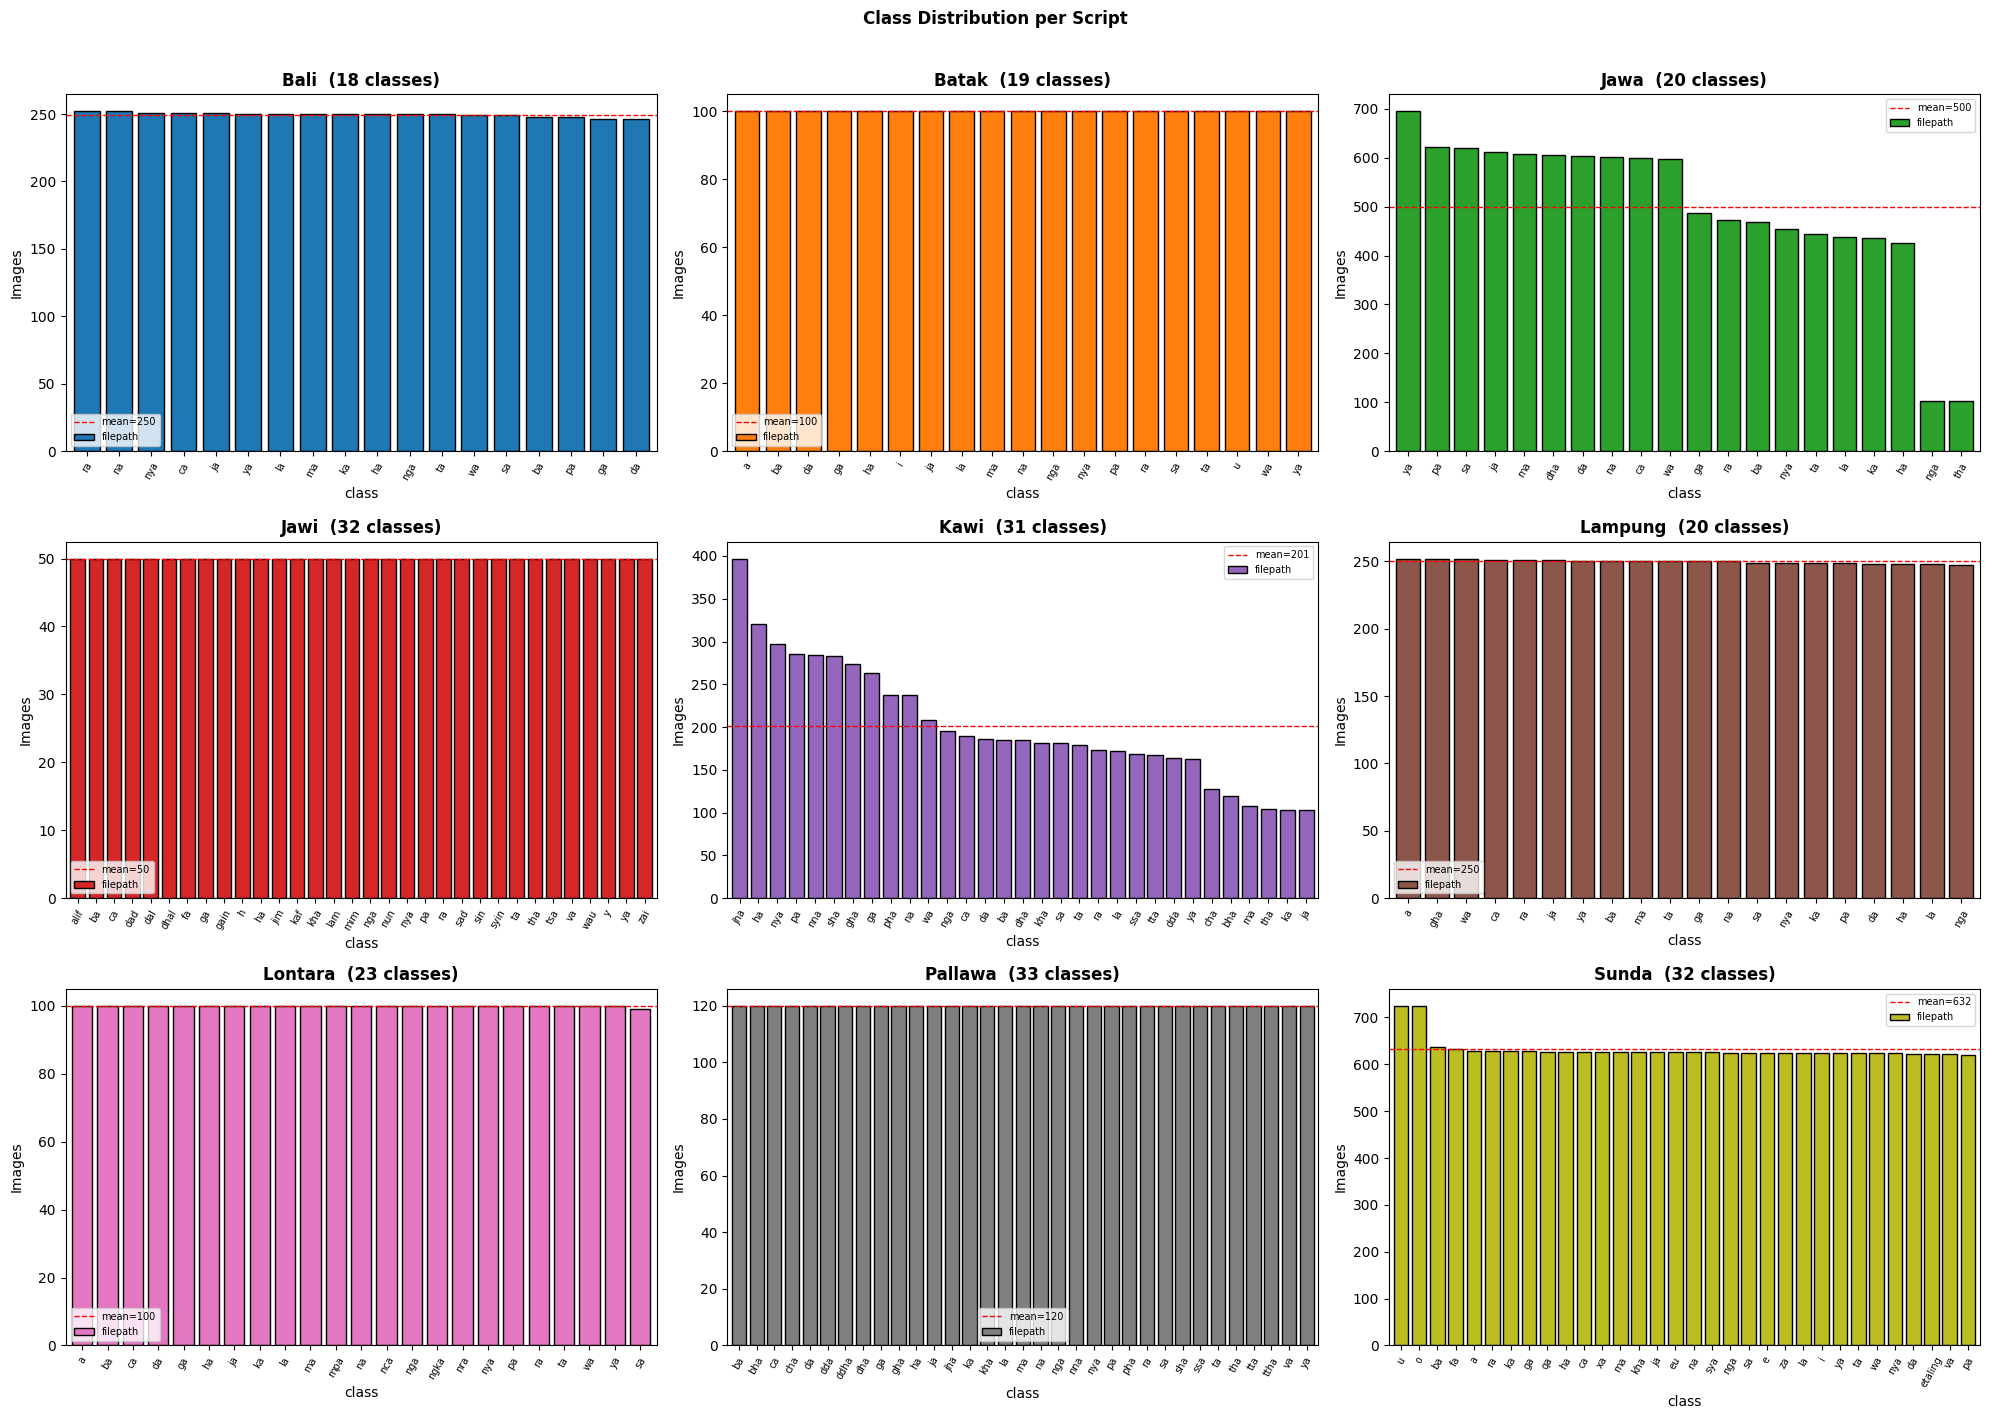

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
for idx, (ax, script) in enumerate(zip(axes.flatten(), sorted(df['script'].unique()))):
    sub = df[df['script'] == script].groupby('class')['filepath'].count().sort_values(ascending=False)
    sub.plot(kind='bar', ax=ax, color=PALETTE[idx], edgecolor='black', width=0.8)
    ax.set_title(f'{script}  ({len(sub)} classes)', fontweight='bold')
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', rotation=60, labelsize=7)
    ax.axhline(sub.mean(), color='red', linestyle='--', linewidth=1, label=f'mean={sub.mean():.0f}')
    ax.legend(fontsize=7)

plt.suptitle('Class Distribution per Script', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

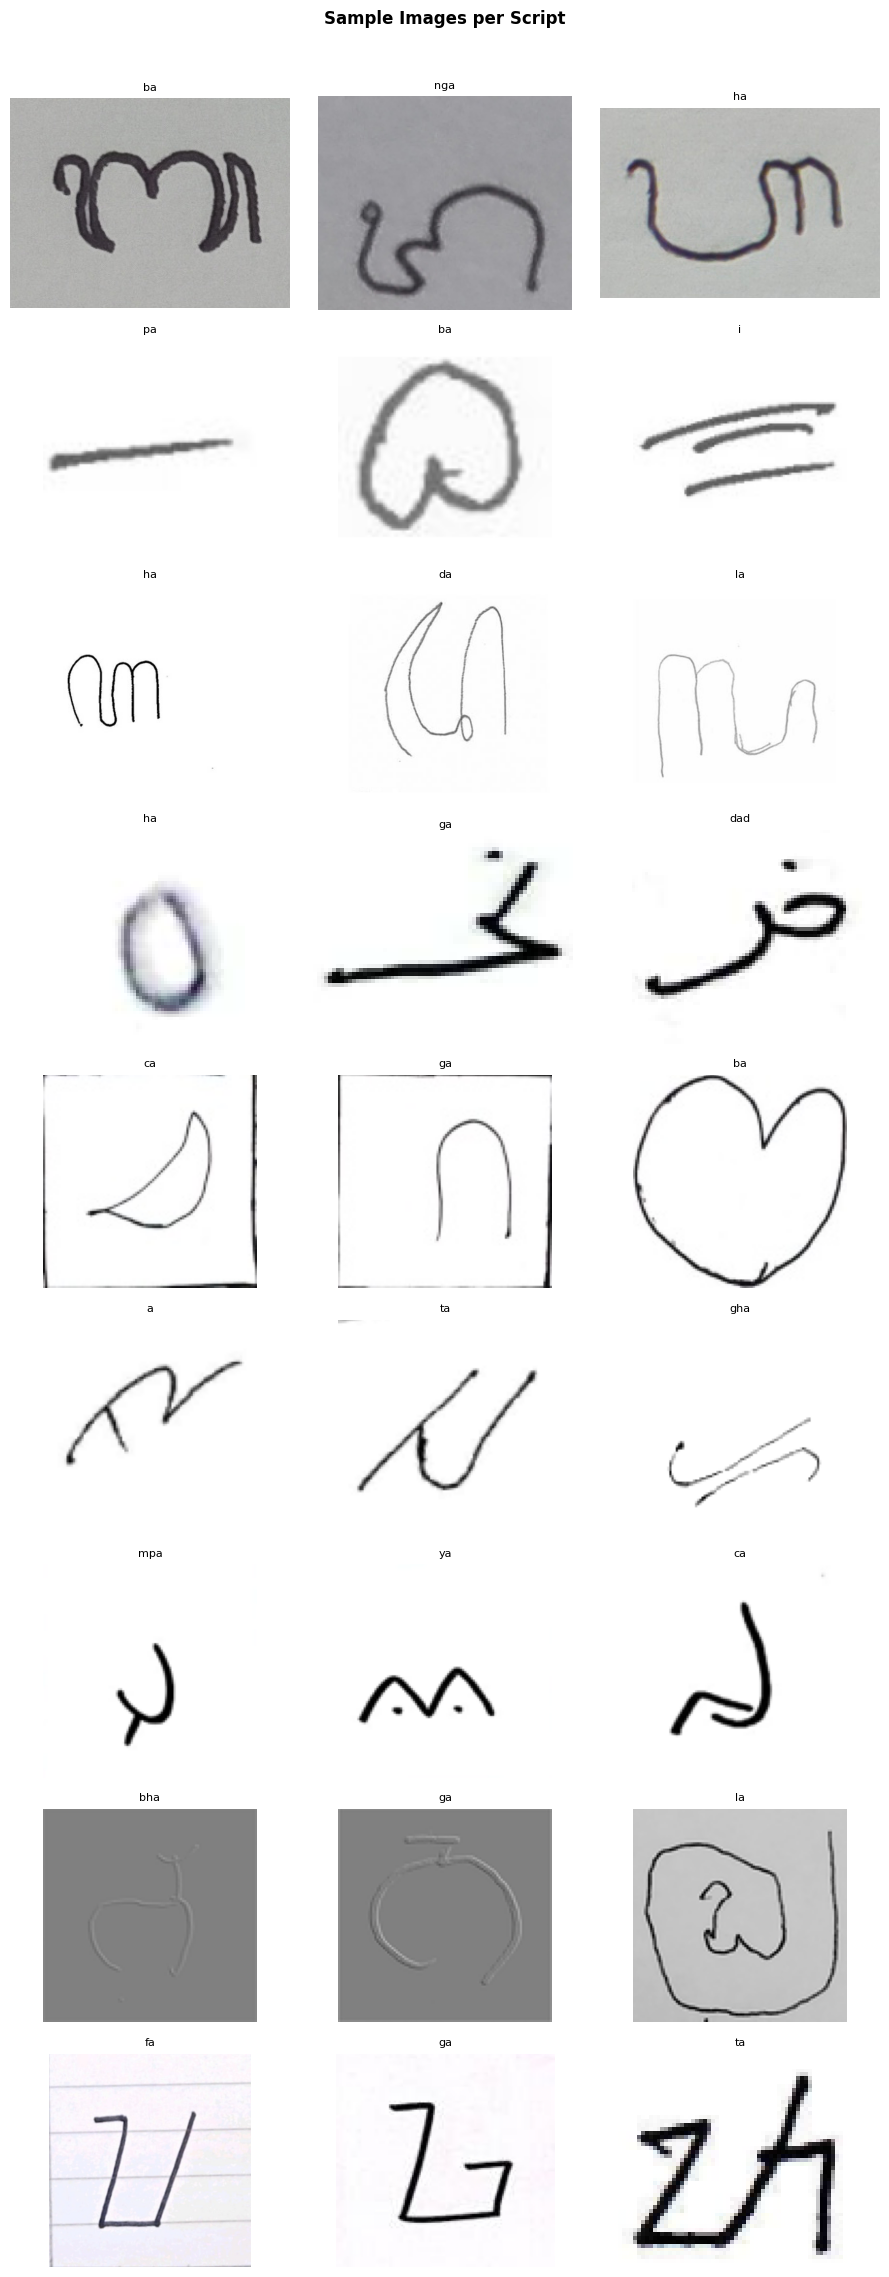

In [8]:
np.random.seed(RANDOM_STATE)
scripts = sorted(df['script'].unique())
N_SAMPLES = 3

fig, axes = plt.subplots(len(scripts), N_SAMPLES, figsize=(N_SAMPLES * 3, len(scripts) * 2.5))
for row, script in enumerate(scripts):
    samples = df[df['script'] == script].sample(n=N_SAMPLES, random_state=RANDOM_STATE)
    for col, (_, rec) in enumerate(samples.iterrows()):
        img = Image.open(rec['filepath']).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(rec['class'], fontsize=8)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(script, fontsize=10, fontweight='bold', rotation=90, labelpad=10)

plt.suptitle('Sample Images per Script', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_sample_images.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Preprocessing & Stratified Split

In [9]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

np.save(OUTPUT_DIR / 'class_names.npy', CLASS_NAMES)
joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')

X_all = df['filepath'].values
y_all = df['label_enc'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all,
)
np.save(FEATURES_DIR / 'labels_train.npy', y_train)
np.save(FEATURES_DIR / 'labels_test.npy',  y_test)

print(f'Classes : {N_CLASSES}')
print(f'Train   : {len(X_train):,}   Test : {len(X_test):,}')

Classes : 228
Train   : 44,570   Test : 11,143


In [10]:
# Preprocessing: grayscale -> mean-blur binarize -> replicate to 3-ch RGB -> normalize
def binarize_pil(gray: Image.Image) -> Image.Image:
    blurred = np.array(gray.filter(ImageFilter.GaussianBlur(radius=1)))
    thresh  = blurred.mean()
    binary  = np.where(np.array(gray) < thresh, 0, 255).astype(np.uint8)
    return Image.fromarray(binary, mode='L')

def to_rgb_3ch(gray: Image.Image) -> Image.Image:
    return Image.merge('RGB', [gray, gray, gray])

BASE_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class NusantaraDataset(Dataset):
    def __init__(self, filepaths, labels):
        self.filepaths = filepaths
        self.labels    = labels

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx])
        if img.mode == 'RGBA':
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            img = bg
        elif img.mode == 'P':
            img = img.convert('RGBA').convert('RGB')
        else:
            img = img.convert('RGB')
        gray   = img.convert('L')
        binary = binarize_pil(gray)
        rgb    = to_rgb_3ch(binary)
        return BASE_TRANSFORM(rgb), int(self.labels[idx])

tensor, lbl = NusantaraDataset(X_train[:1], y_train[:1])[0]
print(f'Tensor shape : {tuple(tensor.shape)}   label : {lbl} -> {CLASS_NAMES[lbl]}')

Tensor shape : (3, 224, 224)   label : 225 -> Sunda_xa


## 3. Feature Extraction — Frozen CNN Backbones

In [11]:
def build_extractor(name: str) -> nn.Module:
    if name == 'mobilenet_v2':
        m = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()
    elif name == 'efficientnet_b0':
        m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()
    else:
        raise ValueError(name)
    for p in m.parameters():
        p.requires_grad = False
    return m.eval().to(DEVICE)

@torch.no_grad()
def extract_features(extractor, filepaths, labels, desc=''):
    ds = NusantaraDataset(filepaths, labels)
    loader = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
    )
    use_amp = (DEVICE.type == 'cuda')
    feats, lbls = [], []
    for imgs, batch_lbls in tqdm(loader, desc=desc, unit='batch'):
        imgs = imgs.to(DEVICE, non_blocking=use_amp)
        if use_amp:
            with torch.cuda.amp.autocast(dtype=torch.float16):
                f = extractor(imgs)
            f = f.float()
        else:
            f = extractor(imgs)
        feats.append(f.cpu().numpy())
        lbls.extend(batch_lbls.numpy().tolist())
    return np.vstack(feats), np.array(lbls)

print('Feature extraction utilities ready.')

Feature extraction utilities ready.


In [12]:
BACKBONES = ['mobilenet_v2', 'efficientnet_b0']
FEATURES  = {}

for bb in BACKBONES:
    tr_path = FEATURES_DIR / f'features_train_{bb}.npy'
    te_path = FEATURES_DIR / f'features_test_{bb}.npy'

    if tr_path.exists() and te_path.exists():
        print(f'[{bb}] loading cached features...')
        X_tr = np.load(tr_path)
        X_te = np.load(te_path)
        y_tr = np.load(FEATURES_DIR / 'labels_train.npy')
        y_te = np.load(FEATURES_DIR / 'labels_test.npy')
    else:
        print(f'\n[{bb}] extracting features...')
        extractor = build_extractor(bb)
        t0 = time.time()
        X_tr, y_tr = extract_features(extractor, X_train, y_train, f'{bb} | train')
        X_te, y_te = extract_features(extractor, X_test,  y_test,  f'{bb} | test')
        print(f'  elapsed: {time.time()-t0:.0f}s')
        np.save(tr_path, X_tr)
        np.save(te_path, X_te)
        del extractor
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
        elif DEVICE.type == 'mps':
            torch.mps.empty_cache()

    FEATURES[bb] = {'train': (X_tr, y_tr), 'test': (X_te, y_te)}
    print(f'  [{bb}] train {X_tr.shape}  test {X_te.shape}')

print('\nFeature extraction complete.')


[mobilenet_v2] extracting features...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 204MB/s]


mobilenet_v2 | train:   0%|          | 0/349 [00:00<?, ?batch/s]

mobilenet_v2 | test:   0%|          | 0/88 [00:00<?, ?batch/s]

  elapsed: 521s
  [mobilenet_v2] train (44570, 1280)  test (11143, 1280)

[efficientnet_b0] extracting features...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 237MB/s]


efficientnet_b0 | train:   0%|          | 0/349 [00:00<?, ?batch/s]

efficientnet_b0 | test:   0%|          | 0/88 [00:00<?, ?batch/s]

  elapsed: 301s
  [efficientnet_b0] train (44570, 1280)  test (11143, 1280)

Feature extraction complete.


## 4. Dimensionality Reduction (PCA 1280 → 256)

In [13]:
PCA_MODELS = {}

for bb in BACKBONES:
    pca_path = FEATURES_DIR / f'pca_{bb}.pkl'
    tr_pca   = FEATURES_DIR / f'features_train_{bb}_pca{PCA_COMPONENTS}.npy'
    te_pca   = FEATURES_DIR / f'features_test_{bb}_pca{PCA_COMPONENTS}.npy'

    X_tr, y_tr = FEATURES[bb]['train']
    X_te, y_te = FEATURES[bb]['test']

    if pca_path.exists() and tr_pca.exists():
        pca      = joblib.load(pca_path)
        X_tr_red = np.load(tr_pca)
        X_te_red = np.load(te_pca)
        print(f'[{bb}] loaded cached PCA features.')
    else:
        print(f'[{bb}] fitting PCA {X_tr.shape[1]} -> {PCA_COMPONENTS} ...')
        pca      = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
        X_tr_red = pca.fit_transform(X_tr).astype(np.float32)
        X_te_red = pca.transform(X_te).astype(np.float32)
        joblib.dump(pca, pca_path)
        np.save(tr_pca, X_tr_red)
        np.save(te_pca, X_te_red)

    PCA_MODELS[bb] = pca
    FEATURES[bb]['train'] = (X_tr_red, y_tr)
    FEATURES[bb]['test']  = (X_te_red, y_te)
    var = pca.explained_variance_ratio_.sum() * 100
    print(f'  variance retained: {var:.1f}%   train {X_tr_red.shape}  test {X_te_red.shape}')

print('\nPCA complete.')

[mobilenet_v2] fitting PCA 1280 -> 256 ...
  variance retained: 95.9%   train (44570, 256)  test (11143, 256)
[efficientnet_b0] fitting PCA 1280 -> 256 ...
  variance retained: 94.1%   train (44570, 256)  test (11143, 256)

PCA complete.


### 4b. Feature Extraction Demo — One Handwritten Image

Step-by-step visualisation of what happens to a single image through the pipeline:
`Raw → Grayscale → Binarise → Resize 224×224 → CNN (MobileNetV2) → 1280-d vector → PCA → 256-d vector`

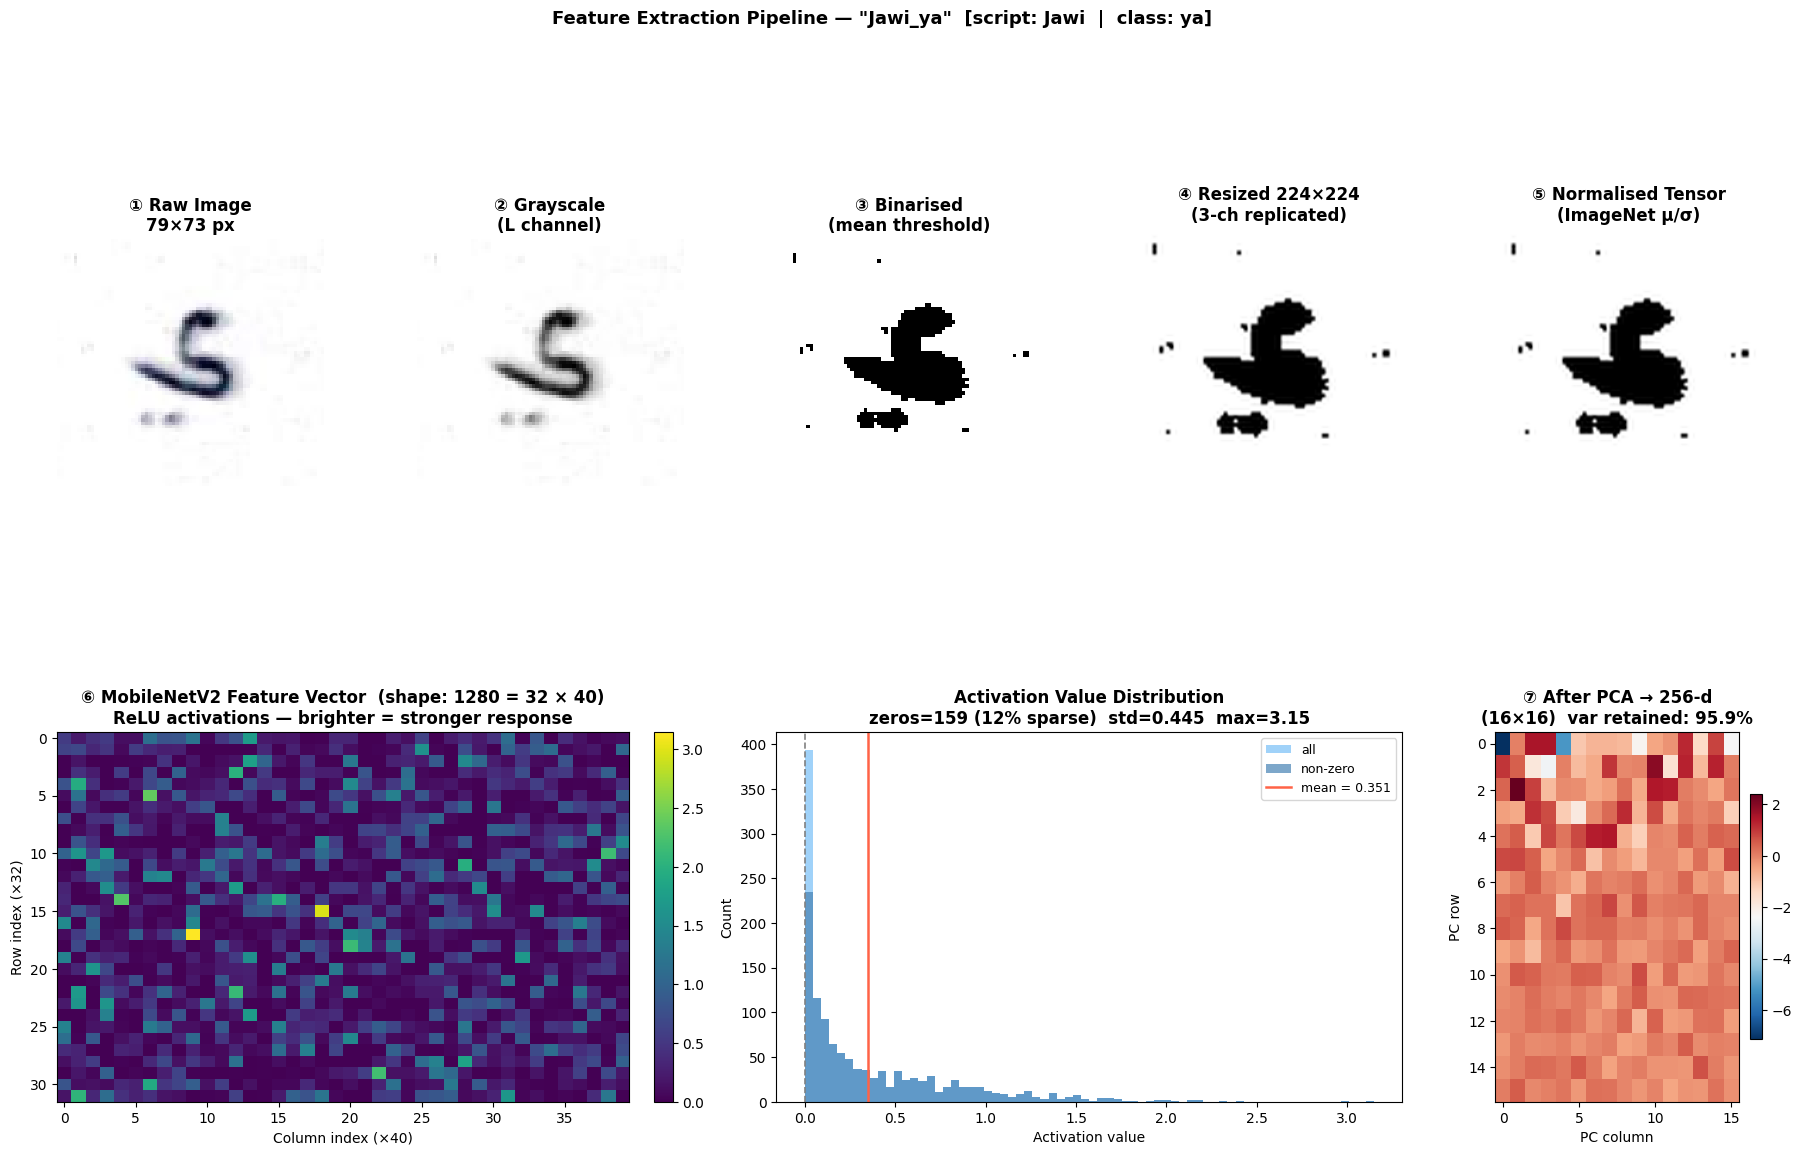

Label   : Jawi_ya
Script  : Jawi  |  Class: ya

[ CNN 1280-d vector ]
  dtype   : float32
  shape   : (1280,)
  min     : 0.0000
  max     : 3.1465
  mean    : 0.3510
  std     : 0.4449
  zeros   : 159 / 1280 (12.4% sparse — due to ReLU)
  first 8 : [0.5527 0.2142 0.426  0.5308 0.1136 0.1227 1.1396 0.8105]

[ PCA 256-d vector ]
  shape   : (256,)
  min     : -7.1403
  max     : 2.3857
  mean    : -0.0452
  std     : 0.8359
  first 8 : [-7.1403  0.0243  1.5276  1.5068 -5.1668 -1.1014 -0.777  -0.756 ]

→ This 256-d vector is the final input to XGBoost / LightGBM / CatBoost.


In [14]:
import matplotlib.gridspec as gridspec

_demo_bb  = 'mobilenet_v2'
_demo_row = df[df['script'] == 'Jawi'].sample(1, random_state=7).iloc[0]
_demo_path = _demo_row['filepath']

# ── Preprocessing pipeline ────────────────────────────────────────────────────
_img_raw = Image.open(_demo_path)
if _img_raw.mode == 'RGBA':
    _bg = Image.new('RGB', _img_raw.size, (255, 255, 255))
    _bg.paste(_img_raw, mask=_img_raw.split()[3])
    _img_raw = _bg
elif _img_raw.mode == 'P':
    _img_raw = _img_raw.convert('RGBA').convert('RGB')
else:
    _img_raw = _img_raw.convert('RGB')

_img_gray   = _img_raw.convert('L')
_img_bin    = binarize_pil(_img_gray)
_img_resize = _img_bin.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
_img_3ch    = to_rgb_3ch(_img_resize)
_tensor     = BASE_TRANSFORM(_img_3ch).unsqueeze(0)

# ── CNN forward pass → 1280-d feature vector ─────────────────────────────────
_demo_ext = build_extractor(_demo_bb)
with torch.no_grad():
    if DEVICE.type == 'cuda':
        with torch.cuda.amp.autocast(dtype=torch.float16):
            _feat_raw = _demo_ext(_tensor.to(DEVICE)).float().cpu()
    else:
        _feat_raw = _demo_ext(_tensor.to(DEVICE)).cpu()
_feat_vec = _feat_raw.numpy().flatten()   # shape: (1280,)
del _demo_ext
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
elif DEVICE.type == 'mps':
    torch.mps.empty_cache()

# ── PCA projection → 256-d ───────────────────────────────────────────────────
_feat_pca = PCA_MODELS[_demo_bb].transform(_feat_vec.reshape(1, -1)).flatten()  # (256,)

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.5, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[0, 3])
ax4 = fig.add_subplot(gs[0, 4])
ax5 = fig.add_subplot(gs[1, 0:2])   # 1280-d heatmap
ax6 = fig.add_subplot(gs[1, 2:4])   # activation histogram
ax7 = fig.add_subplot(gs[1, 4])     # 256-d PCA heatmap

# ── Row 0: preprocessing steps ───────────────────────────────────────────────
ax0.imshow(_img_raw)
ax0.set_title(f'① Raw Image\n{_img_raw.size[0]}×{_img_raw.size[1]} px', fontweight='bold')
ax0.axis('off')

ax1.imshow(_img_gray, cmap='gray')
ax1.set_title('② Grayscale\n(L channel)', fontweight='bold')
ax1.axis('off')

ax2.imshow(_img_bin, cmap='gray')
ax2.set_title('③ Binarised\n(mean threshold)', fontweight='bold')
ax2.axis('off')

ax3.imshow(_img_3ch)
ax3.set_title(f'④ Resized {IMG_SIZE}×{IMG_SIZE}\n(3-ch replicated)', fontweight='bold')
ax3.axis('off')

_t_disp = _tensor.squeeze(0).clone()
for _c, (_m, _s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
    _t_disp[_c] = _t_disp[_c] * _s + _m
ax4.imshow(_t_disp.permute(1, 2, 0).numpy().clip(0, 1))
ax4.set_title('⑤ Normalised Tensor\n(ImageNet μ/σ)', fontweight='bold')
ax4.axis('off')

# ── Row 1, panel 1: 1280-d vector as 32×40 heatmap ───────────────────────────
im5 = ax5.imshow(_feat_vec.reshape(32, 40), cmap='viridis', aspect='auto')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
ax5.set_title(
    f'⑥ MobileNetV2 Feature Vector  (shape: 1280 = 32 × 40)\n'
    f'ReLU activations — brighter = stronger response',
    fontweight='bold',
)
ax5.set_xlabel('Column index (×40)')
ax5.set_ylabel('Row index (×32)')

# ── Row 1, panel 2: histogram of activation values ───────────────────────────
_nonzero = _feat_vec[_feat_vec > 0]
ax6.hist(_feat_vec, bins=70, color='#90CAF9', edgecolor='none', alpha=0.85, label='all')
ax6.hist(_nonzero,  bins=70, color='steelblue', edgecolor='none', alpha=0.7, label='non-zero')
ax6.axvline(_feat_vec.mean(), color='tomato', linewidth=1.8,
            label=f'mean = {_feat_vec.mean():.3f}')
ax6.axvline(0, color='gray', linewidth=1.2, linestyle='--')
ax6.set_title(
    f'Activation Value Distribution\n'
    f'zeros={( _feat_vec == 0).sum()} ({( _feat_vec == 0).mean()*100:.0f}% sparse)  '
    f'std={_feat_vec.std():.3f}  max={_feat_vec.max():.2f}',
    fontweight='bold',
)
ax6.set_xlabel('Activation value'); ax6.set_ylabel('Count'); ax6.legend(fontsize=9)

# ── Row 1, panel 3: PCA 256-d as 16×16 heatmap ───────────────────────────────
im7 = ax7.imshow(_feat_pca.reshape(16, 16), cmap='RdBu_r', aspect='auto')
plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04)
ax7.set_title(
    f'⑦ After PCA → 256-d\n(16×16)  var retained: '
    f'{PCA_MODELS[_demo_bb].explained_variance_ratio_.sum()*100:.1f}%',
    fontweight='bold',
)
ax7.set_xlabel('PC column'); ax7.set_ylabel('PC row')

fig.suptitle(
    f'Feature Extraction Pipeline — "{_demo_row["label"]}"  '
    f'[script: {_demo_row["script"]}  |  class: {_demo_row["class"]}]',
    fontweight='bold', fontsize=13, y=1.02,
)
plt.savefig(OUTPUT_DIR / 'feature_extraction_demo.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Print vector summary ──────────────────────────────────────────────────────
print(f'Label   : {_demo_row["label"]}')
print(f'Script  : {_demo_row["script"]}  |  Class: {_demo_row["class"]}')
print()
print(f'[ CNN 1280-d vector ]')
print(f'  dtype   : {_feat_vec.dtype}')
print(f'  shape   : {_feat_vec.shape}')
print(f'  min     : {_feat_vec.min():.4f}')
print(f'  max     : {_feat_vec.max():.4f}')
print(f'  mean    : {_feat_vec.mean():.4f}')
print(f'  std     : {_feat_vec.std():.4f}')
print(f'  zeros   : {( _feat_vec == 0).sum()} / {len(_feat_vec)} '
      f'({( _feat_vec == 0).mean()*100:.1f}% sparse — due to ReLU)')
print(f'  first 8 : {_feat_vec[:8].round(4)}')
print()
print(f'[ PCA 256-d vector ]')
print(f'  shape   : {_feat_pca.shape}')
print(f'  min     : {_feat_pca.min():.4f}')
print(f'  max     : {_feat_pca.max():.4f}')
print(f'  mean    : {_feat_pca.mean():.4f}')
print(f'  std     : {_feat_pca.std():.4f}')
print(f'  first 8 : {_feat_pca[:8].round(4)}')
print()
print('→ This 256-d vector is the final input to XGBoost / LightGBM / CatBoost.')

## 5. Class Weights (Cost-Sensitive Learning)

Classes weighted : 228
Min / mean / max : 0.337  1.891  4.887


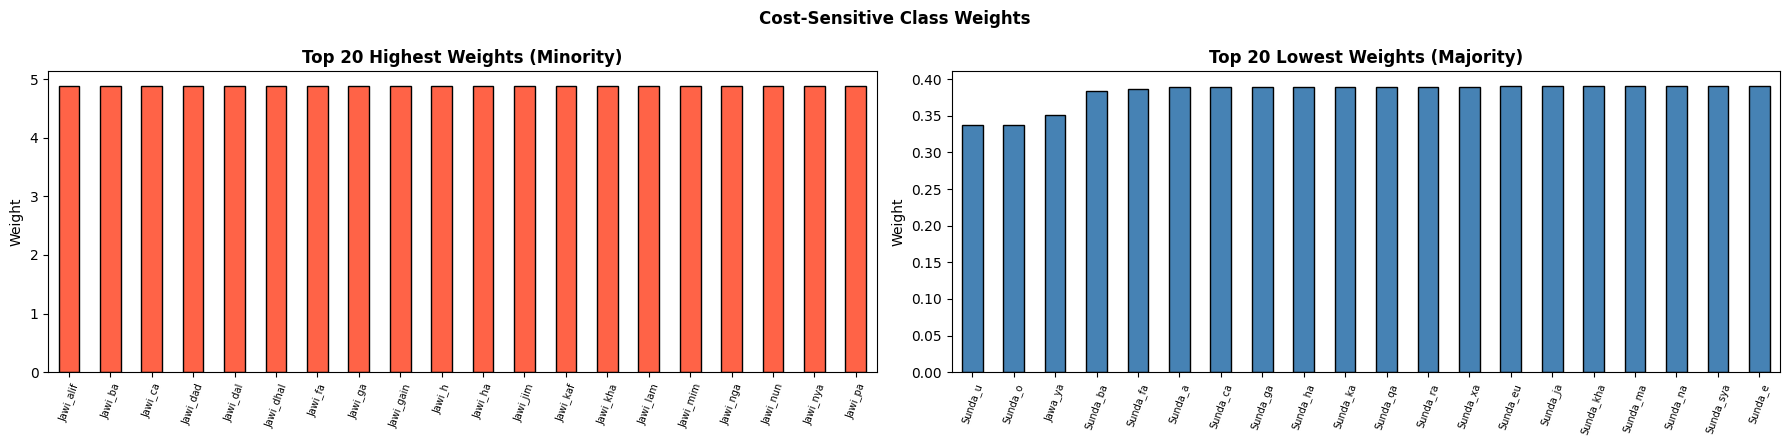

In [15]:
y_ref      = FEATURES[BACKBONES[0]]['train'][1]
unique_cls = np.unique(y_ref)
cw_arr     = compute_class_weight('balanced', classes=unique_cls, y=y_ref)
cw_dict    = dict(zip(unique_cls.tolist(), cw_arr.tolist()))

print(f'Classes weighted : {len(cw_arr)}')
print(f'Min / mean / max : {cw_arr.min():.3f}  {cw_arr.mean():.3f}  {cw_arr.max():.3f}')

ws = pd.Series(cw_arr, index=[CLASS_NAMES[i] for i in unique_cls])
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
ws.nlargest(20).plot(kind='bar',  ax=axes[0], color='tomato',    edgecolor='black')
ws.nsmallest(20).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[0].set_title('Top 20 Highest Weights (Minority)', fontweight='bold')
axes[1].set_title('Top 20 Lowest Weights (Majority)',  fontweight='bold')
for ax in axes:
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', rotation=70, labelsize=7)
plt.suptitle('Cost-Sensitive Class Weights', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_weights.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Hyperparameter Tuning (Optuna TPE)

In [16]:
def get_tune_splits(X, y, sw=None):
    _, sub_idx = train_test_split(
        np.arange(len(y)), test_size=TUNE_SUBSAMPLE,
        stratify=y, random_state=RANDOM_STATE,
    )
    Xs, ys = X[sub_idx], y[sub_idx]
    sws    = sw[sub_idx] if sw is not None else None
    tr, va = next(StratifiedShuffleSplit(1, test_size=0.15, random_state=RANDOM_STATE).split(Xs, ys))
    return Xs[tr], ys[tr], Xs[va], ys[va], (sws[tr] if sws is not None else None)

def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def xgb_objective(trial, X_tr, y_tr, X_va, y_va, sw_tr):
    params = dict(
        n_estimators          = trial.suggest_int('n_estimators', 100, 350, step=50),
        max_depth             = trial.suggest_int('max_depth', 4, 8),
        learning_rate         = trial.suggest_float('learning_rate', 0.05, 0.25, log=True),
        subsample             = trial.suggest_float('subsample', 0.7, 1.0),
        colsample_bytree      = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        eval_metric           = 'mlogloss',
        tree_method           = 'hist',
        device                = 'cuda' if USE_GPU_TREES else 'cpu',
        early_stopping_rounds = 20,
        random_state          = RANDOM_STATE,
        n_jobs                = -1,
        verbosity             = 0,
    )
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_va, y_va)], verbose=False)
    return macro_f1(y_va, model.predict(X_va))

def lgbm_objective(trial, X_tr, y_tr, X_va, y_va):
    # LightGBM builds num_class trees per round — keep n_estimators small for 228 classes
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 30, 120, step=15),
        num_leaves        = trial.suggest_int('num_leaves', 15, 63),
        learning_rate     = trial.suggest_float('learning_rate', 0.05, 0.25, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 80),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        objective         = 'multiclass',
        metric            = 'multi_logloss',
        class_weight      = cw_dict,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbose           = -1,
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr, eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)],
    )
    return macro_f1(y_va, model.predict(X_va))

def cat_objective(trial, X_tr, y_tr, X_va, y_va):
    params = dict(
        iterations          = trial.suggest_int('iterations', 100, 350, step=50),
        depth               = trial.suggest_int('depth', 4, 8),
        learning_rate       = trial.suggest_float('learning_rate', 0.03, 0.25, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        loss_function       = 'MultiClass',
        eval_metric         = 'MultiClass',
        class_weights       = list(cw_arr),
        random_seed         = RANDOM_STATE,
        verbose             = False,
        allow_writing_files = False,
    )
    if USE_GPU_TREES:
        params.update(task_type='GPU', devices=CAT_DEVICES)
    model = CatBoostClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=20)
    return macro_f1(y_va, model.predict(X_va).flatten())

n_tune = int(len(y_train) * TUNE_SUBSAMPLE)
print(f'Tuning on ~{n_tune:,} samples x {PCA_COMPONENTS}-d | {OPTUNA_TRIALS} trials/model')

Tuning on ~13,371 samples x 256-d | 20 trials/model


In [17]:
BEST_PARAMS = {}

for bb in BACKBONES:
    X_full, y_full = FEATURES[bb]['train']
    sw_full        = np.array([cw_dict[c] for c in y_full])
    X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t = get_tune_splits(X_full, y_full, sw_full)

    print(f'\n{"="*55}')
    print(f'  {bb}  |  tune: {len(y_tr_t):,} train  {len(y_va_t):,} val')
    print(f'{"="*55}')

    objectives = [
        ('xgb',  lambda t: xgb_objective(t,  X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t)),
        ('lgbm', lambda t: lgbm_objective(t, X_tr_t, y_tr_t, X_va_t, y_va_t)),
        ('cat',  lambda t: cat_objective(t,  X_tr_t, y_tr_t, X_va_t, y_va_t)),
    ]
    for name, fn in objectives:
        print(f'  Tuning {name.upper()} ...')
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(fn, n_trials=OPTUNA_TRIALS, show_progress_bar=False)
        BEST_PARAMS[(bb, name)] = study.best_params
        print(f'    best val macro-F1: {study.best_value:.4f}')

joblib.dump(BEST_PARAMS, OUTPUT_DIR / 'best_params.pkl')
print('\nTuning complete.')


  mobilenet_v2  |  tune: 11,365 train  2,006 val
  Tuning XGB ...
    best val macro-F1: 0.7287
  Tuning LGBM ...
    best val macro-F1: 0.7071
  Tuning CAT ...
    best val macro-F1: 0.7679

  efficientnet_b0  |  tune: 11,365 train  2,006 val
  Tuning XGB ...
    best val macro-F1: 0.7429
  Tuning LGBM ...
    best val macro-F1: 0.6984
  Tuning CAT ...
    best val macro-F1: 0.7693

Tuning complete.


In [18]:
for (bb, mk), params in BEST_PARAMS.items():
    print(f'\n[{bb}] [{mk.upper()}]')
    for k, v in params.items():
        print(f'  {k:<22} = {v}')


[mobilenet_v2] [XGB]
  n_estimators           = 350
  max_depth              = 7
  learning_rate          = 0.07561716123647681
  subsample              = 0.7053885626844458
  colsample_bytree       = 0.8560354009870226

[mobilenet_v2] [LGBM]
  n_estimators           = 120
  num_leaves             = 40
  learning_rate          = 0.09408037591157857
  reg_lambda             = 0.9824955389830209
  min_child_samples      = 80
  colsample_bytree       = 0.9056742027196293

[mobilenet_v2] [CAT]
  iterations             = 350
  depth                  = 5
  learning_rate          = 0.08540936495699429
  l2_leaf_reg            = 1.0781749950753867

[efficientnet_b0] [XGB]
  n_estimators           = 350
  max_depth              = 7
  learning_rate          = 0.0836110920922911
  subsample              = 0.7053885626844458
  colsample_bytree       = 0.6058053867520206

[efficientnet_b0] [LGBM]
  n_estimators           = 120
  num_leaves             = 38
  learning_rate          = 0.090510790138

## 7. Final Model Training

In [23]:
MODEL_DISPLAY = {'xgb': 'XGBoost', 'lgbm': 'LightGBM', 'cat': 'CatBoost'}
TRAINED      = {}
TRAIN_CURVES = {}   # eval history per (backbone, model_key); used by Section 7b


class _XGBProgress(xgb.callback.TrainingCallback):
    def __init__(self, total, every=50):
        self.total = total
        self.every = every
        self.t0    = None

    def before_training(self, model):
        self.t0 = time.time()
        return model

    def after_iteration(self, model, epoch, evals_log):
        r = epoch + 1
        if r == 1 or r % self.every == 0 or r == self.total:
            parts = [f'round {r:>4}/{self.total}']
            for dname, mdict in evals_log.items():
                for mname, vals in mdict.items():
                    parts.append(f'{dname}_{mname}={vals[-1]:.4f}')
            parts.append(f'elapsed={time.time()-self.t0:.0f}s')
            print('    ' + '  '.join(parts))
        return False


def _lgbm_progress(every, total):
    _t0 = [time.time()]

    def _cb(env):
        r = env.iteration + 1
        if r == 1 or r % every == 0 or r == total:
            parts = [f'round {r:>4}/{total}']
            for item in (env.evaluation_result_list or []):
                parts.append(f'{item[1]}={item[2]:.4f}')
            parts.append(f'elapsed={time.time()-_t0[0]:.0f}s')
            print('    ' + '  '.join(parts))

    _cb.order = 0
    return _cb


LOG_EVERY = 50


for bb in BACKBONES:
    X_tr, y_tr = FEATURES[bb]['train']
    sw = np.array([cw_dict[c] for c in y_tr])
    print(f'\n{"="*60}')
    print(f'  [{bb}]  {len(X_tr):,} samples x {X_tr.shape[1]} features')
    print(f'{"="*60}')

    # 5% stratified holdout — eval display + learning curve capture
    _sss = StratifiedShuffleSplit(n_splits=1, test_size=0.05, random_state=RANDOM_STATE)
    _tr_p, _va_p = next(_sss.split(X_tr, y_tr))
    X_tr_p, y_tr_p, sw_p = X_tr[_tr_p], y_tr[_tr_p], sw[_tr_p]
    X_va_p, y_va_p        = X_tr[_va_p], y_tr[_va_p]

    # --- XGBoost ---
    xp = {**BEST_PARAMS[(bb, 'xgb')],
          'n_estimators': FINAL_ESTIMATORS, 'eval_metric': 'mlogloss',
          'tree_method': 'hist', 'device': 'cuda' if USE_GPU_TREES else 'cpu',
          'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': 0}
    print(f'\n  [XGBoost]  {FINAL_ESTIMATORS} rounds  lr={xp.get("learning_rate", 0):.4f}')
    t0 = time.time()

    # Fit on 95% with 5% holdout to capture eval curves
    xgb_prog = xgb.XGBClassifier(**xp, callbacks=[_XGBProgress(FINAL_ESTIMATORS, every=LOG_EVERY)])
    xgb_prog.fit(
        X_tr_p, y_tr_p, sample_weight=sw_p,
        eval_set=[(X_tr_p, y_tr_p), (X_va_p, y_va_p)],
        verbose=False,
    )
    _er = xgb_prog.evals_result()
    TRAIN_CURVES[(bb, 'xgb')] = {
        'train':  _er['validation_0']['mlogloss'],
        'val':    _er['validation_1']['mlogloss'],
        'metric': 'mlogloss',
        'lr':     xp.get('learning_rate', 0),
    }

    # Refit on full training set for final predictions
    xgb_final = xgb.XGBClassifier(**xp)
    xgb_final.fit(X_tr, y_tr, sample_weight=sw, verbose=False)
    print(f'  -> Refit on full data done  ({time.time()-t0:.0f}s total)')
    joblib.dump(xgb_final, OUTPUT_DIR / f'{bb}_xgb.pkl')
    TRAINED[(bb, 'xgb')] = xgb_final

    # --- LightGBM ---
    lp = {**BEST_PARAMS[(bb, 'lgbm')],
          'n_estimators': LGBM_ESTIMATORS, 'objective': 'multiclass',
          'metric': 'multi_logloss', 'class_weight': cw_dict,
          'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1}
    print(f'\n  [LightGBM]  {LGBM_ESTIMATORS} rounds  lr={lp.get("learning_rate", 0):.4f}')
    t0 = time.time()
    lgbm_model = lgb.LGBMClassifier(**lp)
    lgbm_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va_p, y_va_p)],
        callbacks=[
            lgb.log_evaluation(-1),
            _lgbm_progress(every=max(1, LGBM_ESTIMATORS // 8), total=LGBM_ESTIMATORS),
        ],
    )
    _er = lgbm_model.evals_result_
    _vk = list(_er.keys())[-1]
    TRAIN_CURVES[(bb, 'lgbm')] = {
        'train':  None,   # train eval skipped — 228 classes x N rounds on full set is too slow
        'val':    _er[_vk]['multi_logloss'],
        'metric': 'multi_logloss',
        'lr':     lp.get('learning_rate', 0),
    }
    print(f'  -> Done  ({time.time()-t0:.0f}s)')
    joblib.dump(lgbm_model, OUTPUT_DIR / f'{bb}_lgbm.pkl')
    TRAINED[(bb, 'lgbm')] = lgbm_model

    # --- CatBoost ---
    cp = BEST_PARAMS[(bb, 'cat')]
    cat_kwargs = dict(
        iterations=FINAL_ESTIMATORS, depth=cp.get('depth', 6),
        learning_rate=cp.get('learning_rate', 0.1), l2_leaf_reg=cp.get('l2_leaf_reg', 3.0),
        loss_function='MultiClass', eval_metric='MultiClass',
        class_weights=list(cw_arr), random_seed=RANDOM_STATE,
        verbose=LOG_EVERY, allow_writing_files=False,
    )
    if USE_GPU_TREES:
        cat_kwargs.update(task_type='GPU', devices=CAT_DEVICES)
    print(f'\n  [CatBoost]  {FINAL_ESTIMATORS} rounds  lr={cp.get("learning_rate", 0):.4f}')
    t0 = time.time()
    cat_model = CatBoostClassifier(**cat_kwargs)
    cat_model.fit(X_tr, y_tr, eval_set=(X_va_p, y_va_p))
    _er = cat_model.get_evals_result()
    _ck = list(_er.get('learn', _er.get('validation', {'MultiClass': None})).keys())[0]
    TRAIN_CURVES[(bb, 'cat')] = {
        'train':  list(_er.get('learn', {}).get(_ck, [])) or None,
        'val':    list(_er.get('validation', {}).get(_ck, [])),
        'metric': 'MultiClass loss',
        'lr':     cp.get('learning_rate', 0),
    }
    print(f'  -> Done  ({time.time()-t0:.0f}s)')
    cat_model.save_model(str(OUTPUT_DIR / f'{bb}_catboost.cbm'))
    TRAINED[(bb, 'cat')] = cat_model

print('\nAll 6 models trained and saved.')


  [mobilenet_v2]  44,570 samples x 256 features

  [XGBoost]  500 rounds  lr=0.0756
    round    1/500  validation_0_mlogloss=4.5366  validation_1_mlogloss=4.6913  elapsed=1s
    round   50/500  validation_0_mlogloss=0.3946  validation_1_mlogloss=1.2751  elapsed=64s
    round  100/500  validation_0_mlogloss=0.0983  validation_1_mlogloss=0.8640  elapsed=121s
    round  150/500  validation_0_mlogloss=0.0415  validation_1_mlogloss=0.7332  elapsed=169s
    round  200/500  validation_0_mlogloss=0.0245  validation_1_mlogloss=0.6728  elapsed=210s
    round  250/500  validation_0_mlogloss=0.0174  validation_1_mlogloss=0.6400  elapsed=245s
    round  300/500  validation_0_mlogloss=0.0137  validation_1_mlogloss=0.6196  elapsed=276s
    round  350/500  validation_0_mlogloss=0.0115  validation_1_mlogloss=0.6060  elapsed=306s
    round  400/500  validation_0_mlogloss=0.0100  validation_1_mlogloss=0.5959  elapsed=334s
    round  450/500  validation_0_mlogloss=0.0089  validation_1_mlogloss=0.5878  e

### 7b. Learning Curves

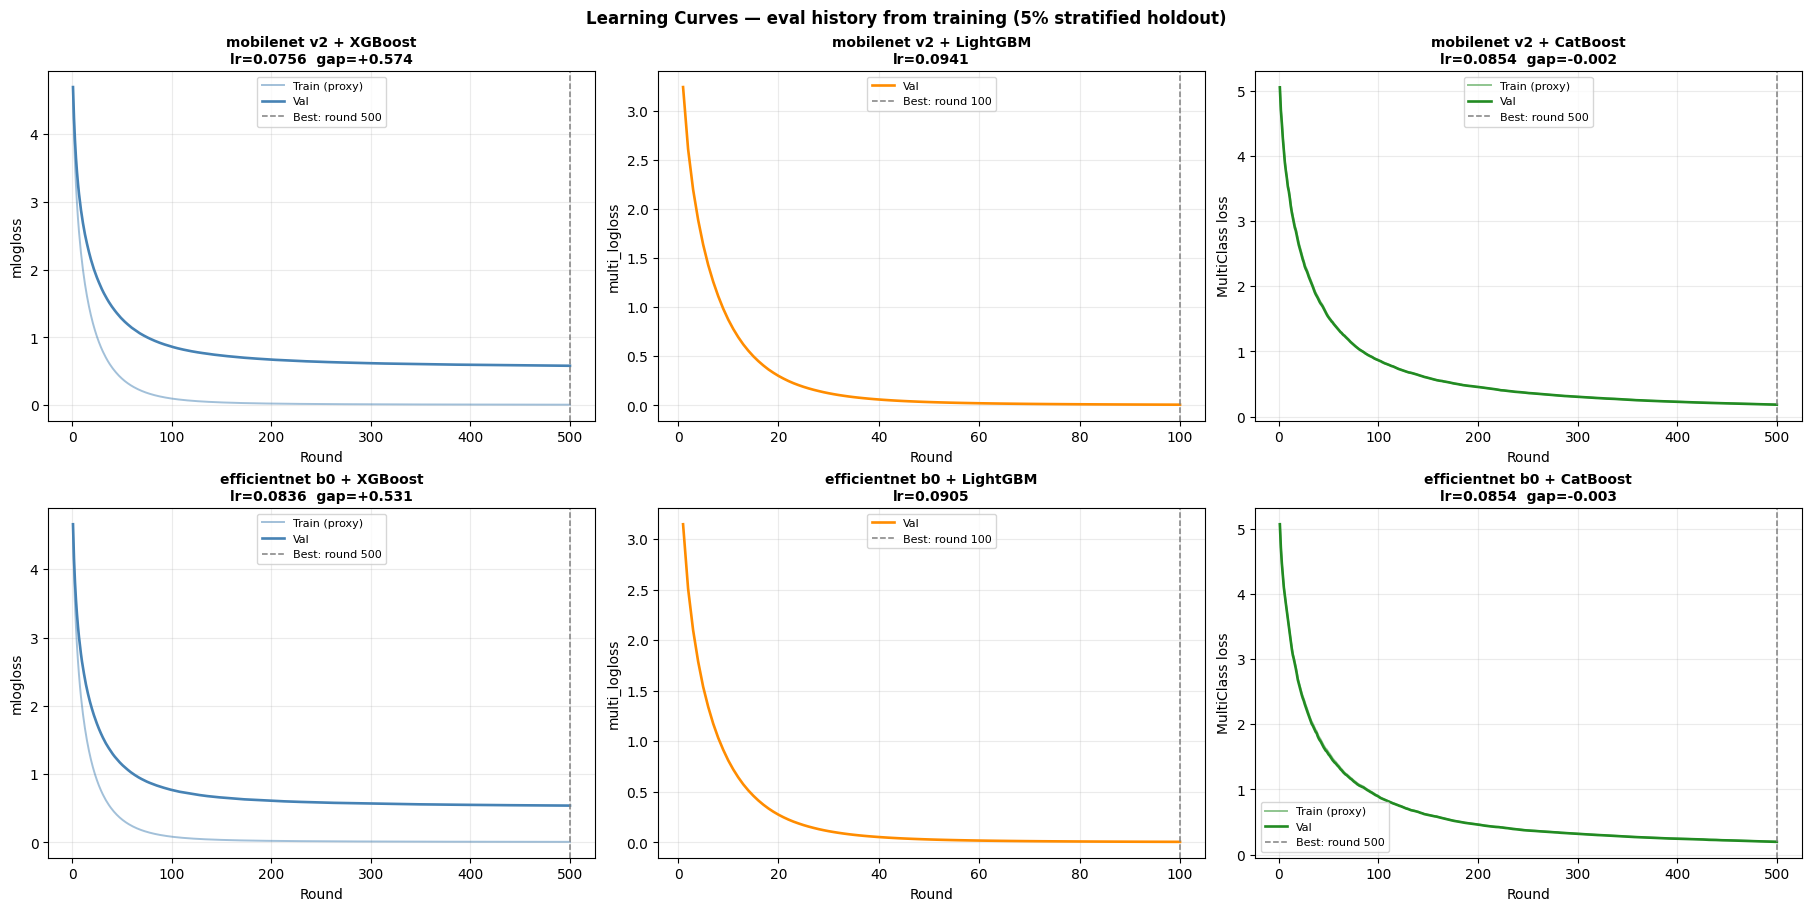

Convergence diagnosis:
  [mobilenet_v2] XGBoost     lr=0.0756  gap=+0.5737  trend=+0.0000  -> OVERFIT
  [mobilenet_v2] LightGBM    lr=0.0941  gap=N/A       trend=+0.0000  -> OK
  [mobilenet_v2] CatBoost    lr=0.0854  gap=-0.0018  trend=+0.0000  -> OK
  [efficientnet_b0] XGBoost     lr=0.0836  gap=+0.5309  trend=+0.0000  -> OVERFIT
  [efficientnet_b0] LightGBM    lr=0.0905  gap=N/A       trend=+0.0000  -> OK
  [efficientnet_b0] CatBoost    lr=0.0854  gap=-0.0033  trend=+0.0000  -> OK


In [24]:
_line_colors = {'xgb': 'steelblue', 'lgbm': 'darkorange', 'cat': 'forestgreen'}

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

for row, bb in enumerate(BACKBONES):
    for col, mk in enumerate(['xgb', 'lgbm', 'cat']):
        ax  = axes[row, col]
        crv = TRAIN_CURVES[(bb, mk)]
        val = crv['val']
        n   = len(val)
        xs  = range(1, n + 1)
        c   = _line_colors[mk]

        if crv['train'] is not None:
            ax.plot(xs, crv['train'], color=c, linewidth=1.4, alpha=0.5, label='Train (proxy)')
        ax.plot(xs, val, color=c, linewidth=1.9, label='Val')

        best_r = int(np.argmin(val)) + 1
        ax.axvline(best_r, color='gray', linestyle='--', linewidth=1.1, label=f'Best: round {best_r}')

        gap_str = ''
        if crv['train'] is not None:
            gap     = float(val[best_r - 1]) - float(crv['train'][best_r - 1])
            gap_str = f'  gap={gap:+.3f}'

        ax.set_title(
            f'{bb.replace("_", " ")} + {MODEL_DISPLAY[mk]}\n'
            f'lr={crv["lr"]:.4f}{gap_str}',
            fontsize=10, fontweight='bold',
        )
        ax.set_xlabel('Round')
        ax.set_ylabel(crv['metric'])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.25)

fig.suptitle(
    'Learning Curves — eval history from training (5% stratified holdout)',
    fontweight='bold', fontsize=12,
)
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print('Convergence diagnosis:')
for bb in BACKBONES:
    for mk in ['xgb', 'lgbm', 'cat']:
        crv    = TRAIN_CURVES[(bb, mk)]
        val    = crv['val']
        best_r = int(np.argmin(val))
        trend  = float(val[-1]) - float(val[best_r])

        if crv['train'] is not None:
            gap    = float(val[best_r]) - float(crv['train'][best_r])
            status = ('OVERFIT' if gap > 0.5 else
                      'MILD OVERFIT' if trend > 0.05 else 'OK')
            gap_str = f'gap={gap:+.4f}  '
        else:
            gap_str = 'gap=N/A       '
            status  = 'MILD OVERFIT' if trend > 0.05 else 'OK'

        print(f'  [{bb}] {MODEL_DISPLAY[mk]:<10}  lr={crv["lr"]:.4f}  '
              f'{gap_str}trend={trend:+.4f}  -> {status}')

## 8. Evaluation

In [25]:
RESULTS, PREDICTIONS, PROBAS = [], {}, {}

for bb in BACKBONES:
    X_te, y_te = FEATURES[bb]['test']
    for mk in ['xgb', 'lgbm', 'cat']:
        model  = TRAINED[(bb, mk)]
        y_pred = np.array(model.predict(X_te)).flatten().astype(int)
        PREDICTIONS[(bb, mk)] = y_pred

        # Collect class probabilities for ensemble (all 3 classifiers support predict_proba)
        PROBAS[(bb, mk)] = model.predict_proba(X_te)   # shape: (n_test, 228)

        acc = accuracy_score(y_te, y_pred)
        mp  = precision_score(y_te, y_pred, average='macro', zero_division=0)
        mr  = recall_score(y_te, y_pred, average='macro', zero_division=0)
        mf1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

        RESULTS.append({
            'Backbone': bb, 'Model': MODEL_DISPLAY[mk],
            'Accuracy': round(acc, 4), 'Macro Precision': round(mp, 4),
            'Macro Recall': round(mr, 4), 'Macro F1': round(mf1, 4),
        })
        print(f'[{bb}] {MODEL_DISPLAY[mk]:<10}  '
              f'F1={mf1:.4f}  Acc={acc:.4f}  P={mp:.4f}  R={mr:.4f}')

[mobilenet_v2] XGBoost     F1=0.8571  Acc=0.8457  P=0.8610  R=0.8578
[mobilenet_v2] LightGBM    F1=0.7976  Acc=0.7846  P=0.7996  R=0.8010
[mobilenet_v2] CatBoost    F1=0.8770  Acc=0.8506  P=0.8778  R=0.8805
[efficientnet_b0] XGBoost     F1=0.8574  Acc=0.8464  P=0.8650  R=0.8561
[efficientnet_b0] LightGBM    F1=0.7957  Acc=0.7840  P=0.8001  R=0.7984
[efficientnet_b0] CatBoost    F1=0.8668  Acc=0.8385  P=0.8681  R=0.8698


In [26]:
results_df = pd.DataFrame(RESULTS).sort_values('Macro F1', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
print('── Model Comparison (sorted by Macro F1) ──')
display(results_df)

── Model Comparison (sorted by Macro F1) ──


,Backbone,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,mobilenet_v2,CatBoost,0.8506,0.8778,0.8805,0.8770
2,efficientnet_b0,CatBoost,0.8385,0.8681,0.8698,0.8668
3,efficientnet_b0,XGBoost,0.8464,0.8650,0.8561,0.8574
4,mobilenet_v2,XGBoost,0.8457,0.8610,0.8578,0.8571
5,mobilenet_v2,LightGBM,0.7846,0.7996,0.8010,0.7976
6,efficientnet_b0,LightGBM,0.7840,0.8001,0.7984,0.7957


---
### 8b. Ensemble Voting — Combining All 6 Models

Three ensemble strategies are evaluated at zero extra training cost:
- **Per-backbone SoftVote**: average probabilities of XGB + LightGBM + CatBoost per backbone
- **SoftVote (6)**: uniform average over all 6 model probability vectors
- **WeightedVote (6)**: weighted average where each model's weight = its individual Macro F1

In [27]:
# Shared test labels — both backbones use the same stratified split
y_te_ens = FEATURES[BACKBONES[0]]['test'][1]

# F1 lookup from individual model results (used for weighted voting)
_f1_map = {(r['Backbone'], r['Model']): r['Macro F1'] for _, r in results_df.iterrows()}

ens_rows = []

# ── Per-backbone soft vote ─────────────────────────────────────────────────────
for bb in BACKBONES:
    p_stack = np.array([PROBAS[(bb, mk)] for mk in ['xgb', 'lgbm', 'cat']])  # (3, n, 228)
    avg_p   = p_stack.mean(axis=0)
    y_pred  = avg_p.argmax(axis=1)
    acc     = accuracy_score(y_te_ens, y_pred)
    mp      = precision_score(y_te_ens, y_pred, average='macro', zero_division=0)
    mr      = recall_score(y_te_ens, y_pred, average='macro', zero_division=0)
    mf1     = f1_score(y_te_ens, y_pred, average='macro', zero_division=0)
    label   = 'SoftVote (XGB+LGBM+CAT)'
    PREDICTIONS[(bb, 'softvote')] = y_pred
    PROBAS[(bb, 'softvote')]      = avg_p
    ens_rows.append({'Backbone': bb, 'Model': label,
                     'Accuracy': round(acc, 4), 'Macro Precision': round(mp, 4),
                     'Macro Recall': round(mr, 4), 'Macro F1': round(mf1, 4)})
    print(f'[{bb}] {label:<28}  F1={mf1:.4f}  Acc={acc:.4f}')

# ── Cross-backbone soft vote (all 6, equal weight) ────────────────────────────
all_keys    = [(bb, mk) for bb in BACKBONES for mk in ['xgb', 'lgbm', 'cat']]
all_p_stack = np.array([PROBAS[k] for k in all_keys])   # (6, n, 228)

avg_all    = all_p_stack.mean(axis=0)
y_pred_all = avg_all.argmax(axis=1)
acc_all    = accuracy_score(y_te_ens, y_pred_all)
mp_all     = precision_score(y_te_ens, y_pred_all, average='macro', zero_division=0)
mr_all     = recall_score(y_te_ens, y_pred_all, average='macro', zero_division=0)
mf1_all    = f1_score(y_te_ens, y_pred_all, average='macro', zero_division=0)
PREDICTIONS[('ALL', 'softvote6')] = y_pred_all
PROBAS[('ALL', 'softvote6')]      = avg_all
ens_rows.append({'Backbone': 'ALL', 'Model': 'SoftVote (6 models)',
                 'Accuracy': round(acc_all, 4), 'Macro Precision': round(mp_all, 4),
                 'Macro Recall': round(mr_all, 4), 'Macro F1': round(mf1_all, 4)})
print(f'[ALL 6]  SoftVote (uniform)     F1={mf1_all:.4f}  Acc={acc_all:.4f}')

# ── Weighted soft vote (weight each model by its own Macro F1) ────────────────
f1_vals = np.array([_f1_map[(bb, MODEL_DISPLAY[mk])] for bb, mk in all_keys])
w       = f1_vals / f1_vals.sum()
avg_w   = (all_p_stack * w[:, None, None]).sum(axis=0)
y_pred_w = avg_w.argmax(axis=1)
acc_w    = accuracy_score(y_te_ens, y_pred_w)
mp_w     = precision_score(y_te_ens, y_pred_w, average='macro', zero_division=0)
mr_w     = recall_score(y_te_ens, y_pred_w, average='macro', zero_division=0)
mf1_w    = f1_score(y_te_ens, y_pred_w, average='macro', zero_division=0)
PREDICTIONS[('ALL', 'weighted6')] = y_pred_w
PROBAS[('ALL', 'weighted6')]      = avg_w
ens_rows.append({'Backbone': 'ALL', 'Model': 'WeightedVote (6 models)',
                 'Accuracy': round(acc_w, 4), 'Macro Precision': round(mp_w, 4),
                 'Macro Recall': round(mr_w, 4), 'Macro F1': round(mf1_w, 4)})
print(f'[ALL 6]  WeightedVote           F1={mf1_w:.4f}  Acc={acc_w:.4f}')
print(f'         Weights: {dict(zip([f"{bb}/{mk}" for bb, mk in all_keys], w.round(4)))}')

# ── Combined leaderboard ───────────────────────────────────────────────────────
ens_df = pd.DataFrame(ens_rows)
results_df_full = (
    pd.concat([results_df.reset_index(drop=True), ens_df], ignore_index=True)
      .sort_values('Macro F1', ascending=False)
      .reset_index(drop=True)
)
results_df_full.index += 1
results_df_full.to_csv(OUTPUT_DIR / 'model_comparison_full.csv', index=False)

print('\n── Full Leaderboard (Individual + Ensemble, sorted by Macro F1) ──')
display(results_df_full)

# Update best-overall tracking (used by confusion matrix / report cells below)
_best_full       = results_df_full.iloc[0]
_best_full_bb    = _best_full['Backbone']
_best_full_model = _best_full['Model']
# Map back to predictions key
_ens_label_map = {
    'SoftVote (XGB+LGBM+CAT)' : 'softvote',
    'SoftVote (6 models)'      : 'softvote6',
    'WeightedVote (6 models)'  : 'weighted6',
}
_model_inv = {v: k for k, v in MODEL_DISPLAY.items()}
if _best_full_model in _ens_label_map:
    best_pred_key = (_best_full_bb, _ens_label_map[_best_full_model])
else:
    best_pred_key = (_best_full_bb, _model_inv[_best_full_model])
print(f'\nOverall best: [{_best_full_bb}] {_best_full_model}  '
      f'Macro F1={_best_full["Macro F1"]}')

[mobilenet_v2] SoftVote (XGB+LGBM+CAT)       F1=0.8735  Acc=0.8524
[efficientnet_b0] SoftVote (XGB+LGBM+CAT)       F1=0.8712  Acc=0.8508
[ALL 6]  SoftVote (uniform)     F1=0.9149  Acc=0.8992
[ALL 6]  WeightedVote           F1=0.9160  Acc=0.9003
         Weights: {'mobilenet_v2/xgb': np.float64(0.1697), 'mobilenet_v2/lgbm': np.float64(0.1579), 'mobilenet_v2/cat': np.float64(0.1736), 'efficientnet_b0/xgb': np.float64(0.1697), 'efficientnet_b0/lgbm': np.float64(0.1575), 'efficientnet_b0/cat': np.float64(0.1716)}

── Full Leaderboard (Individual + Ensemble, sorted by Macro F1) ──


,Backbone,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,ALL,WeightedVote (6 models),0.9003,0.9192,0.9170,0.9160
2,ALL,SoftVote (6 models),0.8992,0.9181,0.9161,0.9149
3,mobilenet_v2,CatBoost,0.8506,0.8778,0.8805,0.8770
4,mobilenet_v2,SoftVote (XGB+LGBM+CAT),0.8524,0.8763,0.8745,0.8735
5,efficientnet_b0,SoftVote (XGB+LGBM+CAT),0.8508,0.8769,0.8716,0.8712
6,efficientnet_b0,CatBoost,0.8385,0.8681,0.8698,0.8668
7,efficientnet_b0,XGBoost,0.8464,0.8650,0.8561,0.8574
8,mobilenet_v2,XGBoost,0.8457,0.8610,0.8578,0.8571
9,mobilenet_v2,LightGBM,0.7846,0.7996,0.8010,0.7976
10,efficientnet_b0,LightGBM,0.7840,0.8001,0.7984,0.7957



Overall best: [ALL] WeightedVote (6 models)  Macro F1=0.916


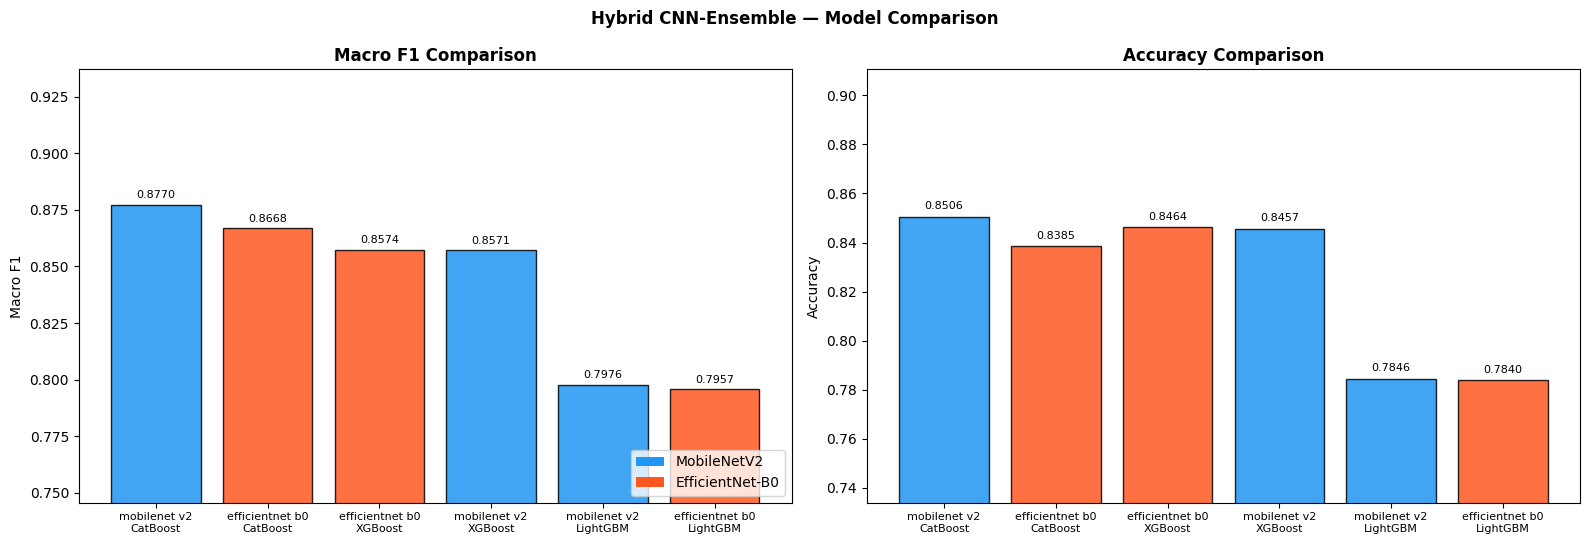

In [28]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
labels = [f"{r['Backbone'].replace('_',' ')}\n{r['Model']}" for _, r in results_df.iterrows()]
colors = ['#2196F3' if 'mobilenet' in r['Backbone'] else '#FF5722' for _, r in results_df.iterrows()]

for ax, metric in zip(axes, ['Macro F1', 'Accuracy']):
    vals = results_df[metric].values
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.06))
    ax.tick_params(axis='x', labelsize=8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                f'{v:.4f}', ha='center', fontsize=8)

axes[0].legend(handles=[Patch(facecolor='#2196F3', label='MobileNetV2'),
                         Patch(facecolor='#FF5722', label='EfficientNet-B0')],
                loc='lower right')
plt.suptitle('Hybrid CNN-Ensemble — Model Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [29]:
# Pick best model from full leaderboard (individual + ensemble)
best_row    = results_df_full.iloc[0]
best_bb     = best_row['Backbone'] if best_row['Backbone'] in BACKBONES else BACKBONES[0]
y_te_best   = FEATURES[BACKBONES[0]]['test'][1]   # y_test is shared across all backbones
y_pred_best = PREDICTIONS[best_pred_key]

report = classification_report(
    y_te_best, y_pred_best, target_names=CLASS_NAMES, digits=4, zero_division=0,
)
with open(OUTPUT_DIR / 'best_model_report.txt', 'w') as f:
    f.write(f"{best_row['Backbone']} + {best_row['Model']}  Macro-F1={best_row['Macro F1']}\n\n{report}")

print(f"Best: [{best_row['Backbone']}] + [{best_row['Model']}]  Macro-F1={best_row['Macro F1']}\n")
print(report)

Best: [ALL] + [WeightedVote (6 models)]  Macro-F1=0.916

               precision    recall  f1-score   support

      Bali_ba     0.6939    0.6800    0.6869        50
      Bali_ca     0.8444    0.7600    0.8000        50
      Bali_da     0.7843    0.8163    0.8000        49
      Bali_ga     0.8947    0.6939    0.7816        49
      Bali_ha     0.8261    0.7600    0.7917        50
      Bali_ja     0.8776    0.8600    0.8687        50
      Bali_ka     0.9400    0.9400    0.9400        50
      Bali_la     0.8269    0.8600    0.8431        50
      Bali_ma     0.8163    0.8000    0.8081        50
      Bali_na     0.8627    0.8800    0.8713        50
     Bali_nga     0.7347    0.7200    0.7273        50
     Bali_nya     0.8036    0.9000    0.8491        50
      Bali_pa     0.7818    0.8600    0.8190        50
      Bali_ra     0.7857    0.8800    0.8302        50
      Bali_sa     0.8431    0.8600    0.8515        50
      Bali_ta     0.7843    0.8000    0.7921        50
      B

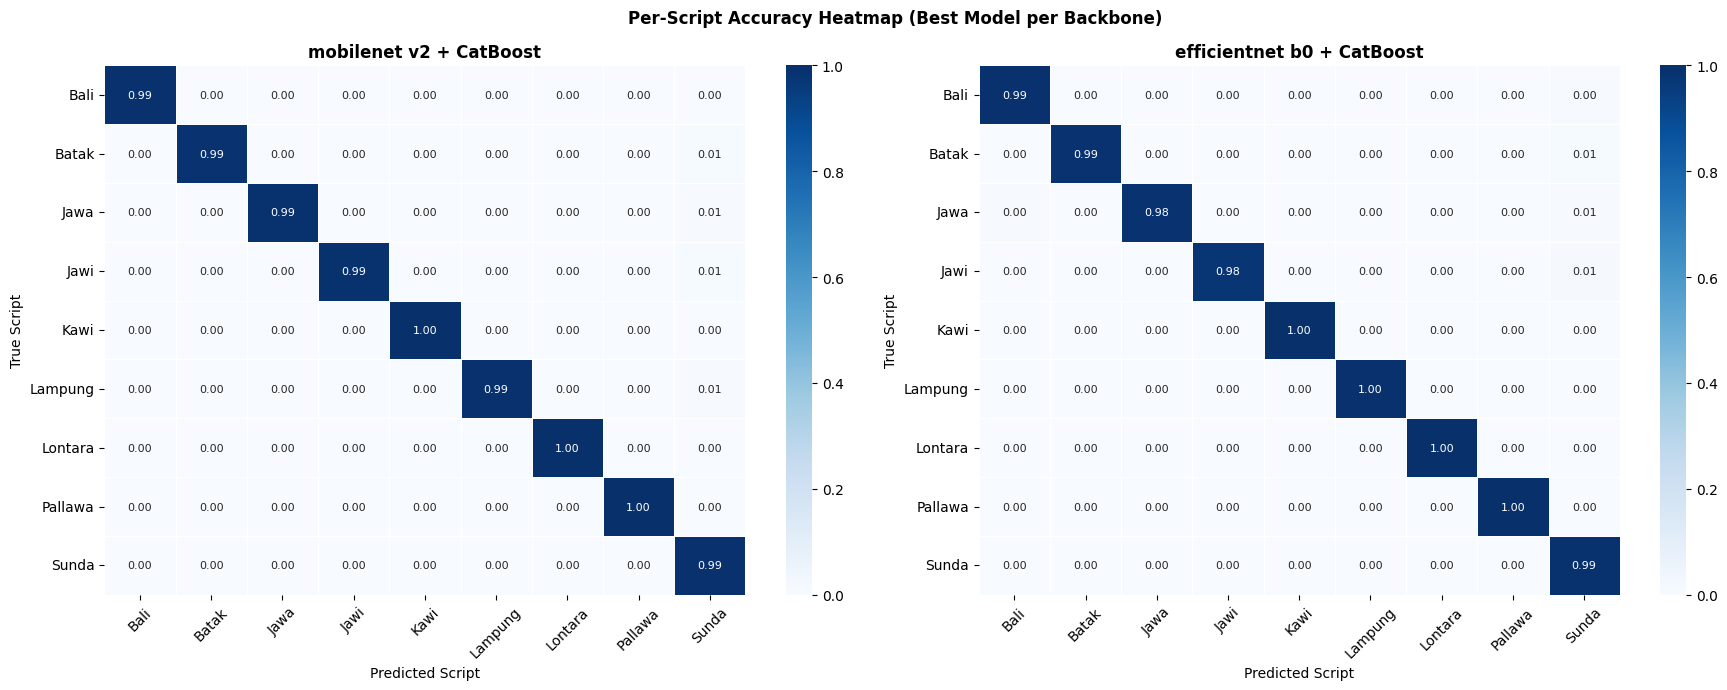

In [30]:
# Per-script accuracy heatmap (9 x 9) for the top model of each backbone
label_to_script = {i: CLASS_NAMES[i].split('_')[0] for i in range(N_CLASSES)}
scripts_ord     = sorted(df['script'].unique())
script_idx      = {s: i for i, s in enumerate(scripts_ord)}

def script_confusion(y_true, y_pred):
    n  = len(scripts_ord)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[script_idx[label_to_script[int(t)]], script_idx[label_to_script[int(p)]]] += 1
    rs = cm.sum(axis=1, keepdims=True)
    return cm / np.where(rs == 0, 1, rs)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, bb in zip(axes, BACKBONES):
    _, y_te_b = FEATURES[bb]['test']
    top_model = results_df[results_df['Backbone'] == bb].iloc[0]['Model']
    top_key   = {v: k for k, v in MODEL_DISPLAY.items()}[top_model]
    sm = script_confusion(y_te_b, PREDICTIONS[(bb, top_key)])
    sns.heatmap(sm, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5,
                xticklabels=scripts_ord, yticklabels=scripts_ord,
                vmin=0, vmax=1, ax=ax, annot_kws={'size': 8})
    ax.set_title(f"{bb.replace('_',' ')} + {top_model}", fontweight='bold')
    ax.set_xlabel('Predicted Script'); ax.set_ylabel('True Script')
    ax.tick_params(axis='x', rotation=45); ax.tick_params(axis='y', rotation=0)

plt.suptitle('Per-Script Accuracy Heatmap (Best Model per Backbone)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_script_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

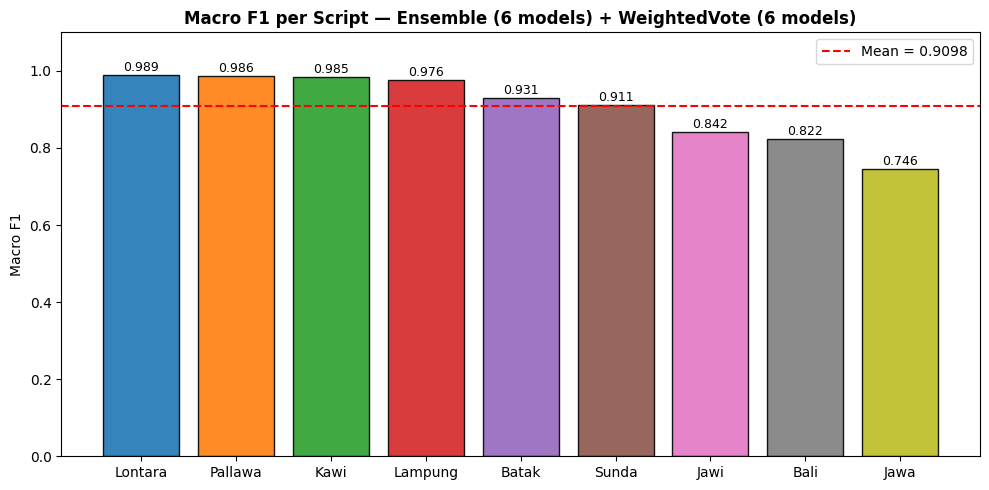

In [31]:
# Macro F1 per script (best overall model)
rep_dict = classification_report(
    y_te_best, y_pred_best, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0,
)
script_f1 = {}
for lbl, vals in rep_dict.items():
    if '_' in lbl and isinstance(vals, dict):
        script_f1.setdefault(lbl.split('_')[0], []).append(vals['f1-score'])
script_f1_mean = pd.Series({s: np.mean(v) for s, v in script_f1.items()}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(script_f1_mean.index, script_f1_mean.values, color=PALETTE, edgecolor='black', alpha=0.9)
ax.axhline(script_f1_mean.mean(), color='red', linestyle='--',
           label=f'Mean = {script_f1_mean.mean():.4f}')
_bb_disp = (best_row['Backbone']
            .replace('mobilenet_v2',   'MobileNetV2')
            .replace('efficientnet_b0', 'EfficientNet-B0')
            .replace('ALL',            'Ensemble (6 models)'))
ax.set_title(f"Macro F1 per Script — {_bb_disp} + {best_row['Model']}",
             fontweight='bold')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.1); ax.legend()
for b, v in zip(bars, script_f1_mean.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'macro_f1_per_script.png', dpi=130, bbox_inches='tight')
plt.show()


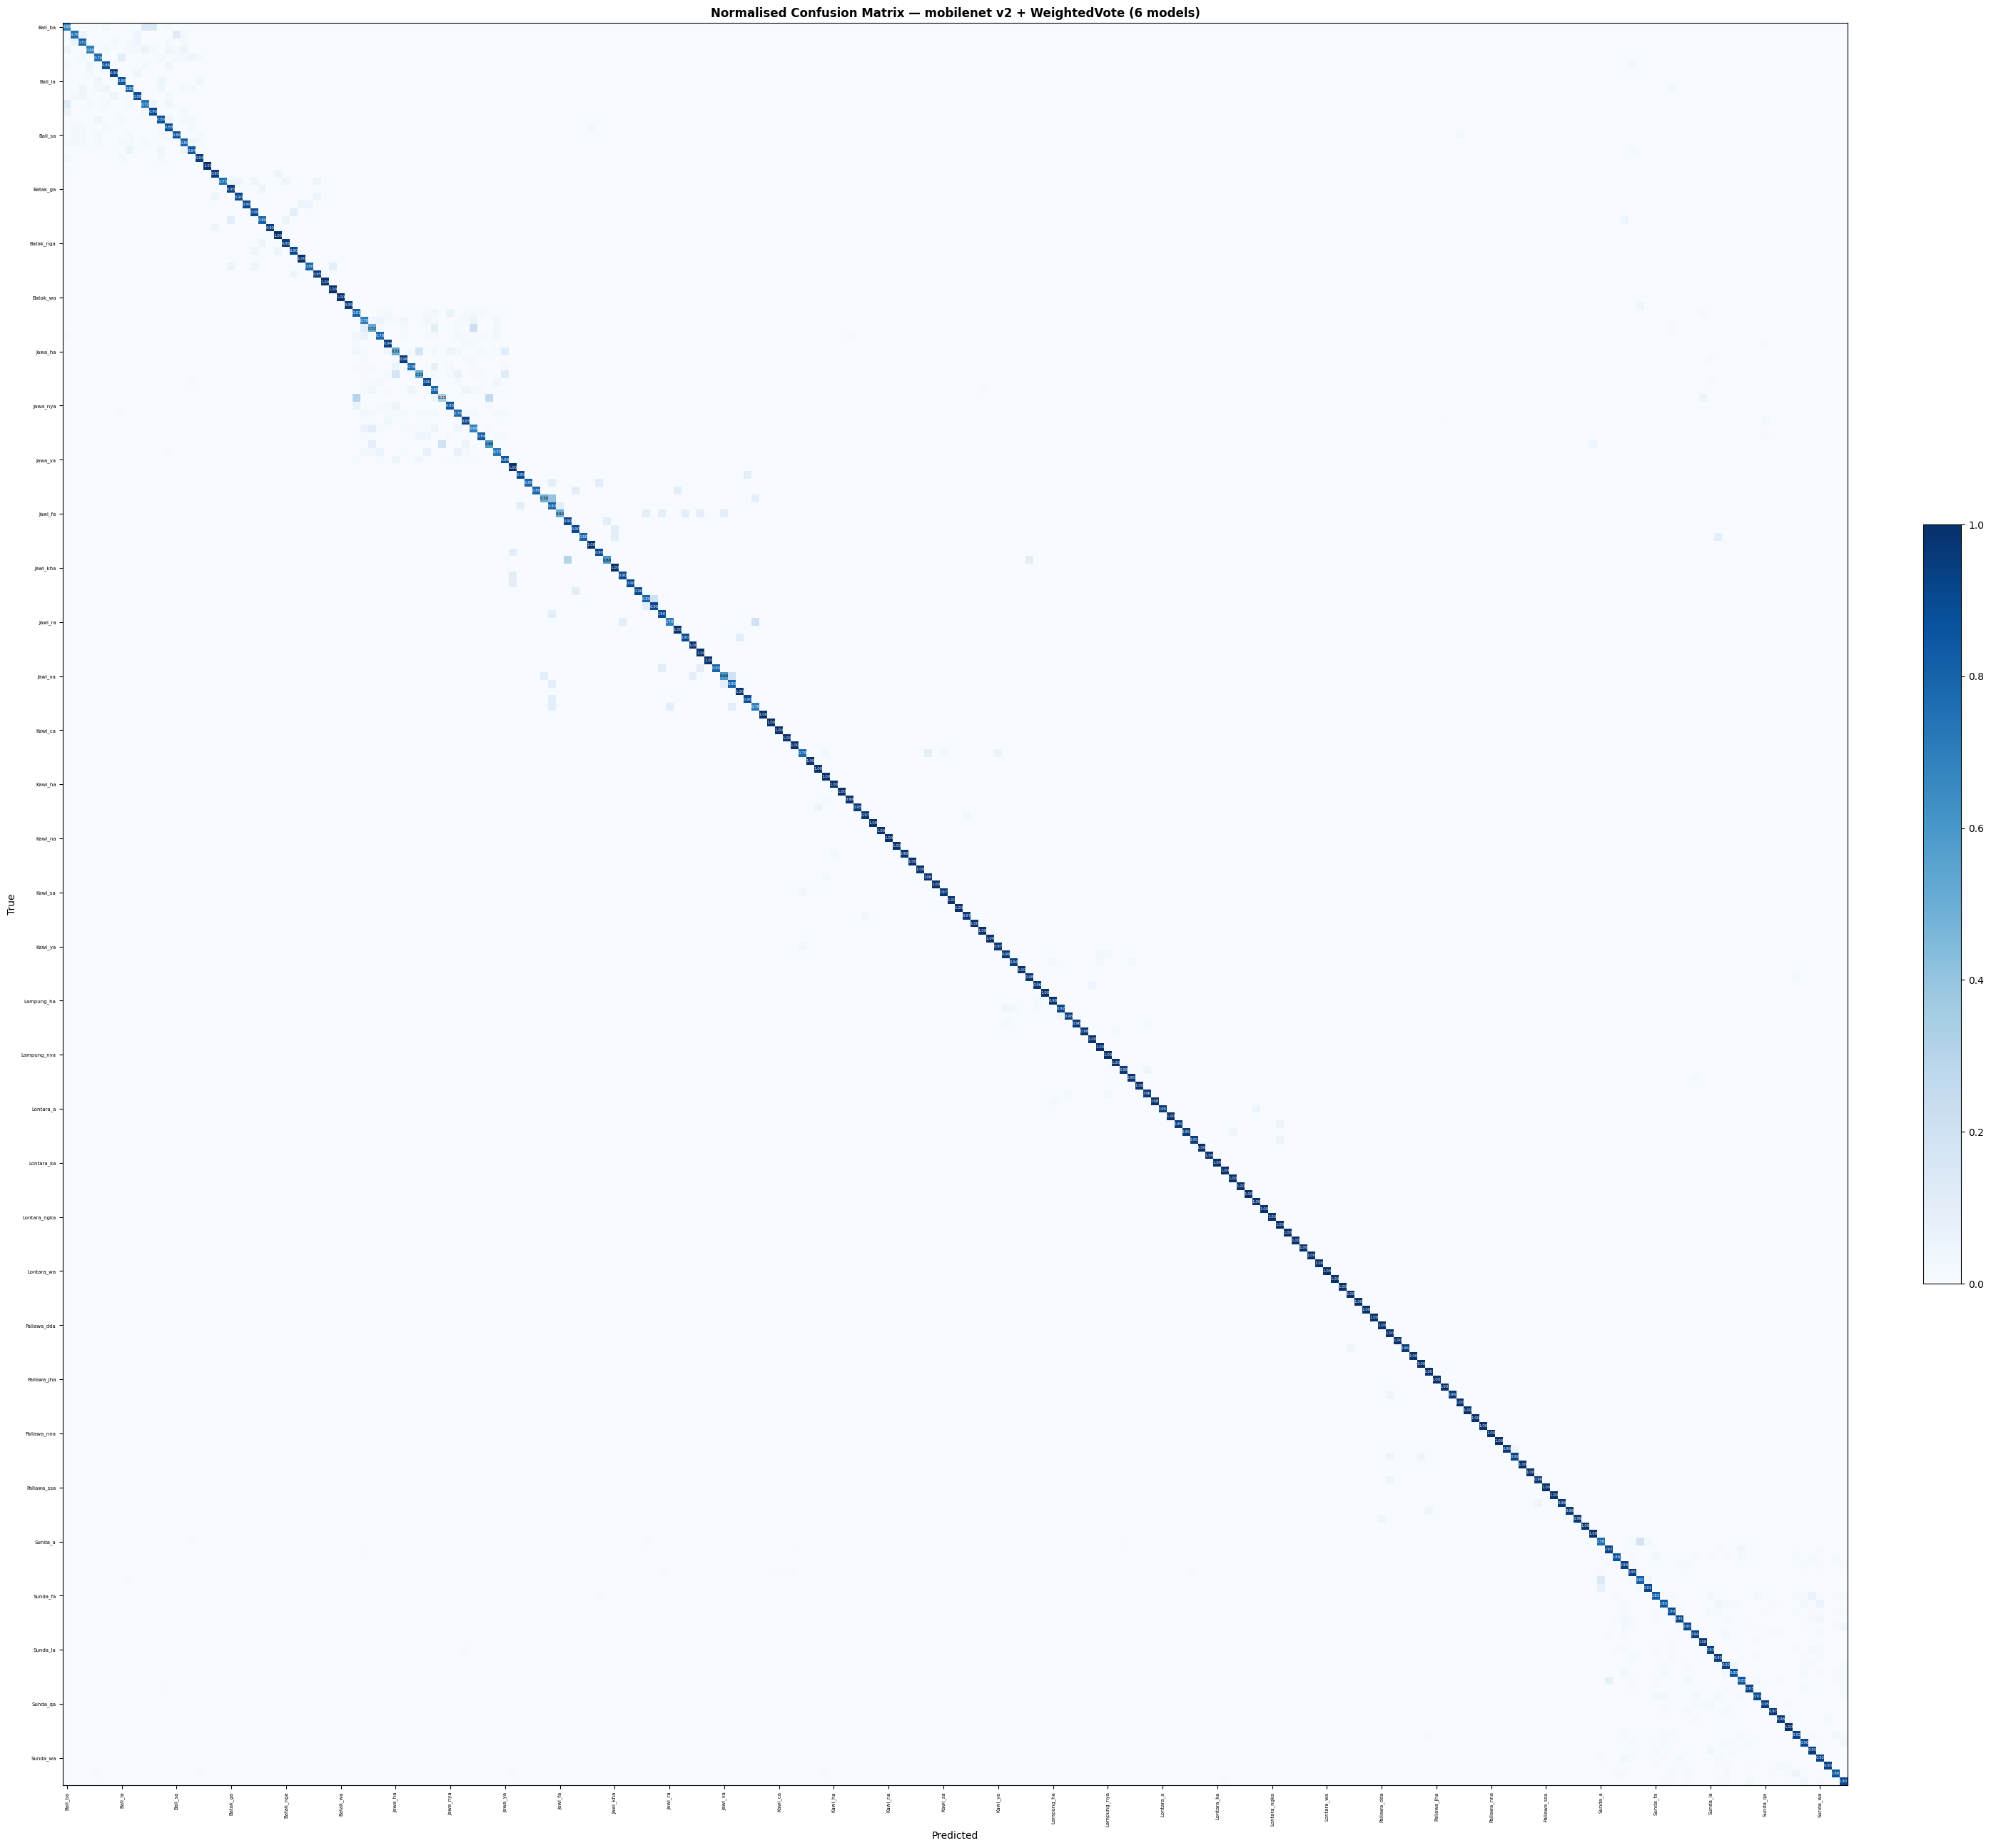

In [32]:
# Full 228x228 confusion matrix for the best model
cm_full = confusion_matrix(y_te_best, y_pred_best)
cm_norm = cm_full.astype(float) / np.where(cm_full.sum(1, keepdims=True) == 0, 1,
                                            cm_full.sum(1, keepdims=True))

fig, ax = plt.subplots(figsize=(28, 26))
im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

for i in range(N_CLASSES):
    ax.text(i, i, f'{cm_norm[i, i]:.2f}', ha='center', va='center',
            fontsize=4, color='white' if cm_norm[i, i] > 0.6 else 'black')

step  = max(1, N_CLASSES // 30)
ticks = list(range(0, N_CLASSES, step))
ax.set_xticks(ticks); ax.set_xticklabels([CLASS_NAMES[i] for i in ticks], rotation=90, fontsize=5)
ax.set_yticks(ticks); ax.set_yticklabels([CLASS_NAMES[i] for i in ticks], fontsize=5)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f"Normalised Confusion Matrix — {best_bb.replace('_',' ')} + {best_row['Model']}",
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_best.png', dpi=130, bbox_inches='tight')
plt.show()

---
### 8c. Per-Script Detailed Evaluation

Aggregated Precision, Recall, and F1 per script with dataset breakdown.
All data is derived from the already-computed classification report — no recomputation.

Per-Script Evaluation  |  Best model: ALL + WeightedVote (6 models)


,Script,Classes,Train,Test,Avg/Class,Macro P,Macro R,Macro F1
0,Lontara,23,1839,460,100.0000,0.9877,0.9913,0.9892
1,Pallawa,33,3168,792,120.0000,0.9844,0.9886,0.9862
2,Kawi,31,4995,1251,201.5000,0.9841,0.9862,0.9849
3,Lampung,20,3997,999,249.8000,0.9762,0.9760,0.9759
4,Batak,19,1520,380,100.0000,0.9370,0.9289,0.9307
5,Sunda,32,16179,4045,632.0000,0.9121,0.9105,0.9107
6,Jawi,32,1280,320,50.0000,0.8546,0.8469,0.8417
7,Bali,18,3595,898,249.6000,0.8228,0.8250,0.8225
8,Jawa,20,7997,1998,499.8000,0.7595,0.7414,0.7464
9,OVERALL,228,44570,11143,244.4000,0.9192,0.9170,0.9160


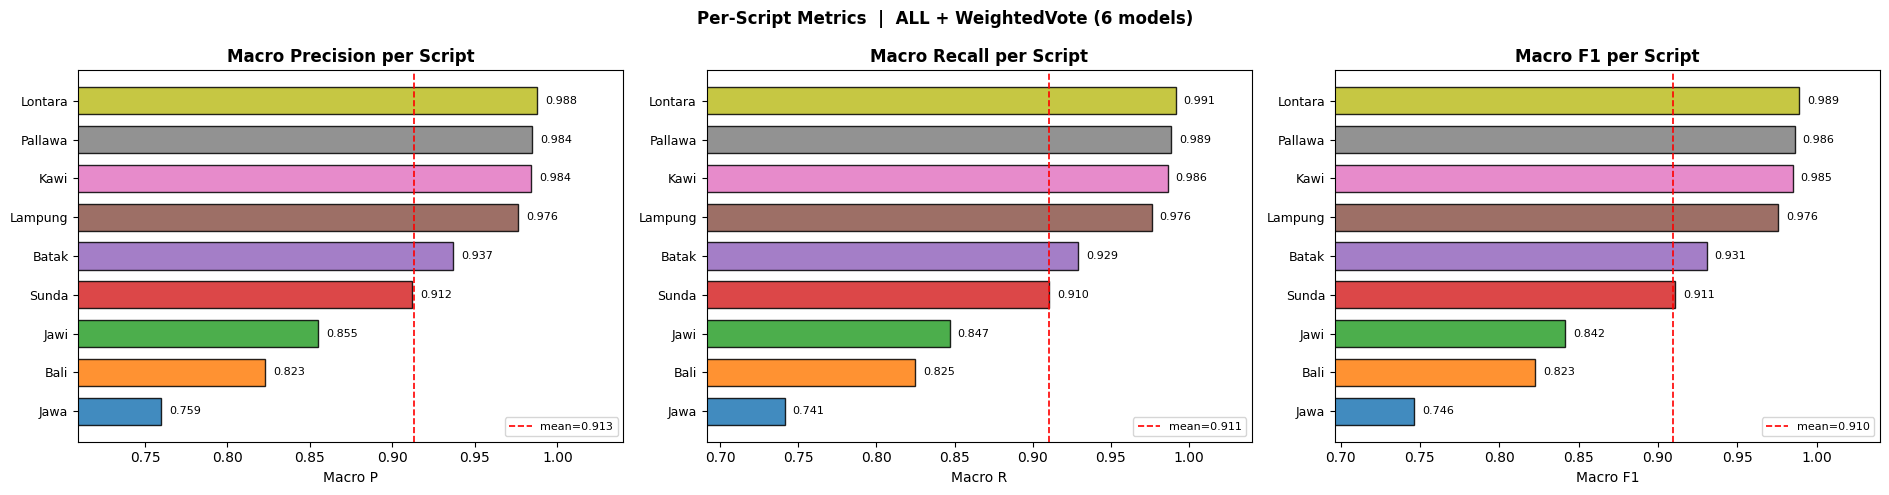

In [33]:
# Per-script train/test counts (vectorised — no loop over full arrays)
_train_script = pd.Series([CLASS_NAMES[y].split('_')[0] for y in y_train]).value_counts()
_test_script  = pd.Series([CLASS_NAMES[y].split('_')[0] for y in y_test]).value_counts()

script_rows = []
for script in sorted(df['script'].unique()):
    cls_list = [c for c in CLASS_NAMES if c.startswith(script + '_')]
    metrics  = [rep_dict[c] for c in cls_list
                if c in rep_dict and isinstance(rep_dict[c], dict)]
    if not metrics:
        continue
    script_rows.append({
        'Script'   : script,
        'Classes'  : len(cls_list),
        'Train'    : int(_train_script.get(script, 0)),
        'Test'     : int(_test_script.get(script, 0)),
        'Avg/Class': round(len(df[df['script'] == script]) / len(cls_list), 1),
        'Macro P'  : round(np.mean([m['precision'] for m in metrics]), 4),
        'Macro R'  : round(np.mean([m['recall']    for m in metrics]), 4),
        'Macro F1' : round(np.mean([m['f1-score']  for m in metrics]), 4),
    })

script_df = (pd.DataFrame(script_rows)
               .sort_values('Macro F1', ascending=False)
               .reset_index(drop=True))
script_df.index += 1

# Overall row
_overall = {
    'Script': 'OVERALL', 'Classes': N_CLASSES,
    'Train': len(y_train), 'Test': len(y_test),
    'Avg/Class': round(len(df) / N_CLASSES, 1),
    'Macro P'  : round(rep_dict['macro avg']['precision'], 4),
    'Macro R'  : round(rep_dict['macro avg']['recall'],    4),
    'Macro F1' : round(rep_dict['macro avg']['f1-score'],  4),
}
script_df_full_table = pd.concat(
    [script_df, pd.DataFrame([_overall])], ignore_index=True
)

print(f'Per-Script Evaluation  |  Best model: '
      f'{best_row["Backbone"].replace("_"," ")} + {best_row["Model"]}')
display(script_df_full_table)
script_df_full_table.to_csv(OUTPUT_DIR / 'per_script_metrics.csv', index=False)

# Horizontal bar chart: P / R / F1 side by side
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, col, title in zip(
    axes,
    ['Macro P', 'Macro R', 'Macro F1'],
    ['Macro Precision per Script', 'Macro Recall per Script', 'Macro F1 per Script'],
):
    data = script_df.set_index('Script')[col].sort_values()
    bars = ax.barh(range(len(data)), data.values,
                   color=PALETTE[:len(data)], edgecolor='black', alpha=0.85, height=0.7)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=9)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'mean={data.mean():.3f}')
    ax.set_xlim(max(0, data.min() - 0.05), 1.04)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    for bar, v in zip(bars, data.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=8)

fig.suptitle(
    f'Per-Script Metrics  |  '
    f'{best_row["Backbone"].replace("_"," ")} + {best_row["Model"]}',
    fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_script_metrics.png', dpi=130, bbox_inches='tight')
plt.show()

---
### 8d. Class-Level Analysis — Best / Worst Classes & Confusion Pairs

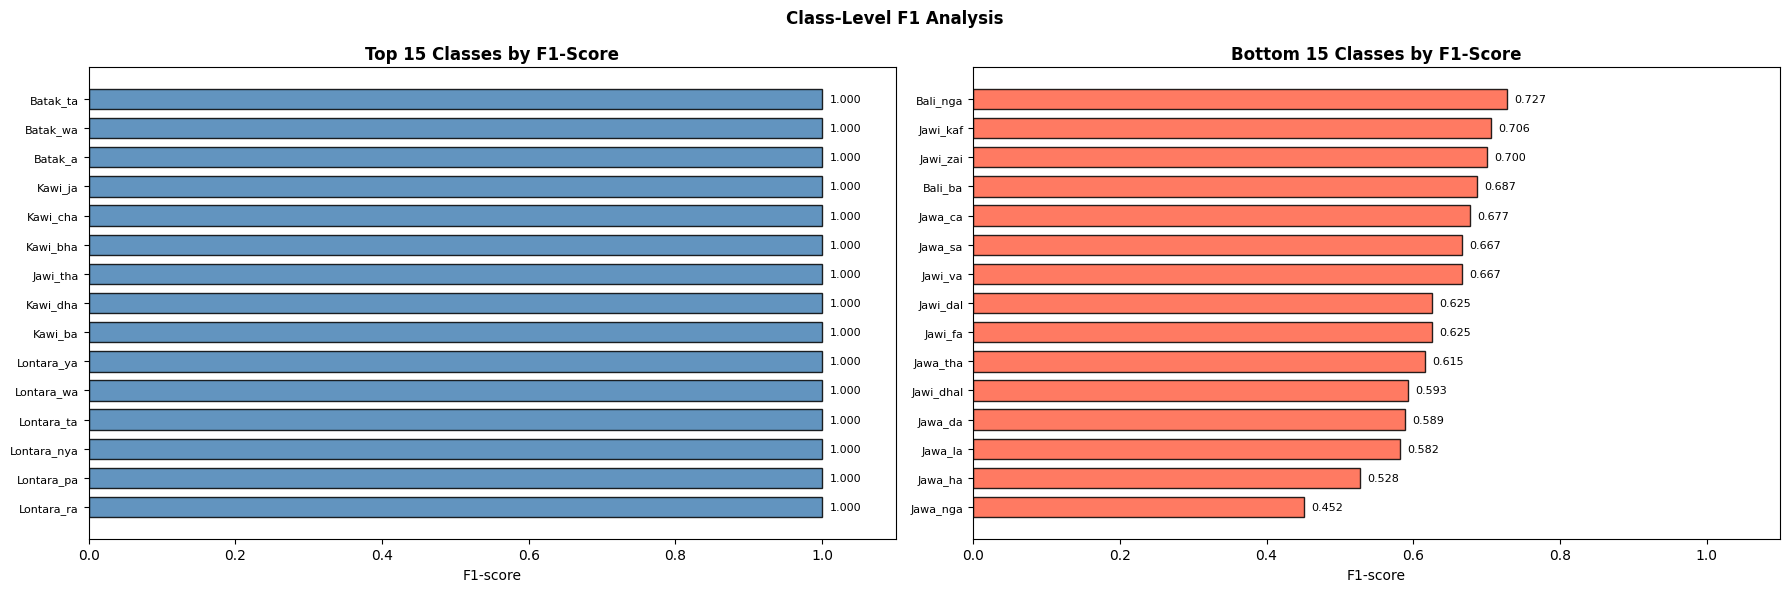

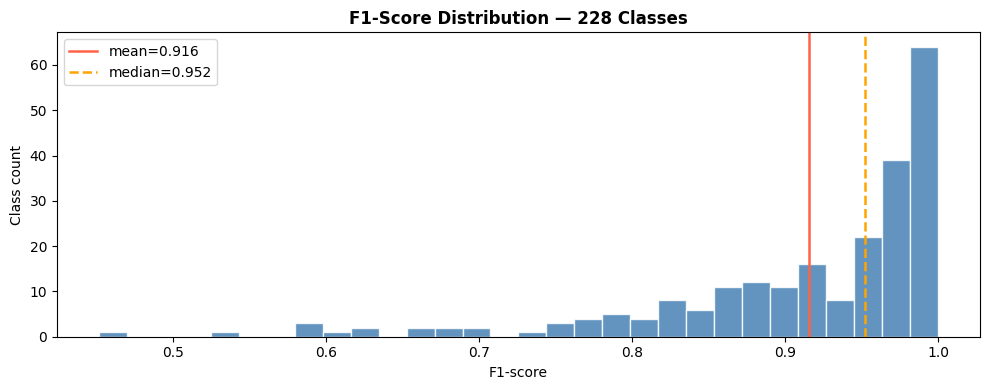

F1 statistics across all classes:
  mean=0.9160  median=0.9524  std=0.1018
  min=0.4516  (Jawa_nga)
  max=1.0000  (Batak_ta)
  F1 >= 0.90 : 156 classes  (68.4%)
  F1 >= 0.80 : 201 classes  (88.2%)
  F1 <  0.50 :   1 classes  (0.4%)

Top-30 confused class pairs  (total error pairs: 560)


,True,Predicted,Count,Error Rate
1,Jawa_da,Jawa_sa,26,0.2150
2,Sunda_a,Sunda_etaling,22,0.1750
3,Sunda_etaling,Sunda_a,16,0.1280
4,Jawa_la,Jawa_ha,15,0.1720
5,Jawa_ha,Jawa_la,15,0.1760
6,Jawa_sa,Jawa_da,13,0.1050
7,Jawa_da,Jawa_ca,13,0.1070
8,Jawa_da,Jawa_na,12,0.0990
9,Jawa_la,Jawa_ya,10,0.1150
10,Jawa_wa,Jawa_ma,9,0.0750


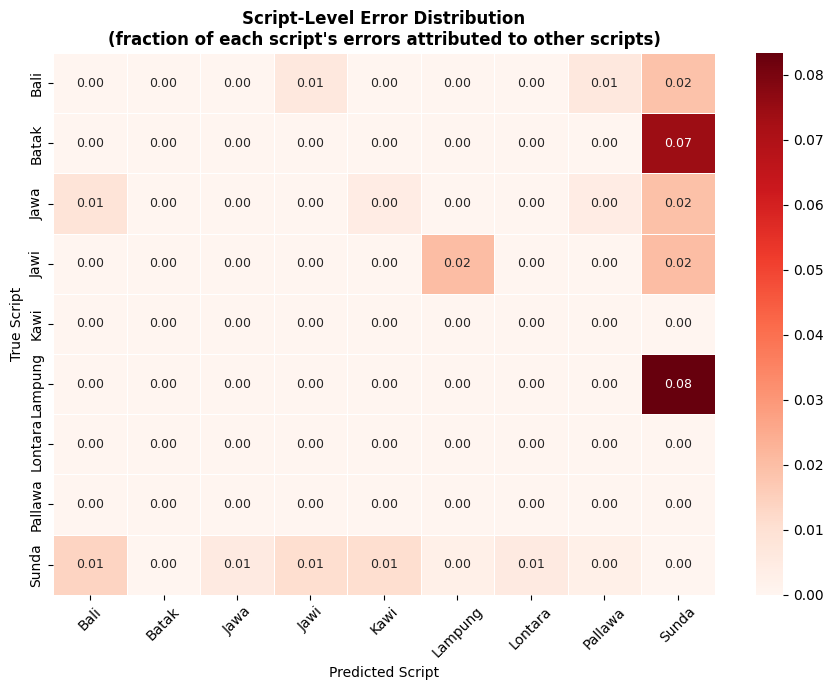

In [34]:
# Class-level F1 series
class_f1_s = pd.Series(
    {c: rep_dict[c]['f1-score']
     for c in CLASS_NAMES
     if c in rep_dict and isinstance(rep_dict[c], dict)}
).sort_values(ascending=False)

top15 = class_f1_s.head(15)
bot15 = class_f1_s.tail(15).sort_values()

# Best / worst class chart
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, data, color, title in [
    (axes[0], top15[::-1], 'steelblue', 'Top 15 Classes by F1-Score'),
    (axes[1], bot15,       'tomato',    'Bottom 15 Classes by F1-Score'),
]:
    bars = ax.barh(range(len(data)), data.values,
                   color=color, edgecolor='black', alpha=0.85, height=0.7)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index, fontsize=8)
    ax.set_xlim(0, 1.1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('F1-score')
    for bar, v in zip(bars, data.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Class-Level F1 Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_f1_best_worst.png', dpi=130, bbox_inches='tight')
plt.show()

# F1 histogram across all 228 classes
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(class_f1_s.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(class_f1_s.mean(),   color='tomato',  linewidth=1.8, label=f'mean={class_f1_s.mean():.3f}')
ax.axvline(class_f1_s.median(), color='orange',  linewidth=1.8, linestyle='--',
           label=f'median={class_f1_s.median():.3f}')
ax.set_title(f'F1-Score Distribution — {N_CLASSES} Classes', fontweight='bold')
ax.set_xlabel('F1-score'); ax.set_ylabel('Class count'); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_f1_histogram.png', dpi=130, bbox_inches='tight')
plt.show()

print('F1 statistics across all classes:')
print(f'  mean={class_f1_s.mean():.4f}  median={class_f1_s.median():.4f}  '
      f'std={class_f1_s.std():.4f}')
print(f'  min={class_f1_s.min():.4f}  ({class_f1_s.idxmin()})')
print(f'  max={class_f1_s.max():.4f}  ({class_f1_s.idxmax()})')
print(f'  F1 >= 0.90 : {(class_f1_s >= 0.90).sum():>3} classes  '
      f'({(class_f1_s >= 0.90).mean()*100:.1f}%)')
print(f'  F1 >= 0.80 : {(class_f1_s >= 0.80).sum():>3} classes  '
      f'({(class_f1_s >= 0.80).mean()*100:.1f}%)')
print(f'  F1 <  0.50 : {(class_f1_s <  0.50).sum():>3} classes  '
      f'({(class_f1_s < 0.50).mean()*100:.1f}%)')

# Top-30 most confused class pairs from the full confusion matrix
confused_pairs = []
for i in range(N_CLASSES):
    row_sum = int(cm_full[i].sum())
    for j in range(N_CLASSES):
        if i != j and cm_full[i, j] > 0:
            confused_pairs.append({
                'True'      : CLASS_NAMES[i],
                'Predicted' : CLASS_NAMES[j],
                'Count'     : int(cm_full[i, j]),
                'Error Rate': round(cm_full[i, j] / max(row_sum, 1), 3),
            })

confused_df = (pd.DataFrame(confused_pairs)
                 .sort_values('Count', ascending=False)
                 .reset_index(drop=True))
confused_df.index += 1
confused_df.to_csv(OUTPUT_DIR / 'confused_pairs.csv', index=False)

print(f'\nTop-30 confused class pairs  (total error pairs: {len(confused_df):,})')
display(confused_df.head(30))

# Confusion heatmap: which SCRIPTS confuse which SCRIPTS
# Uses label_to_script defined in the per-script heatmap cell above
fig, ax = plt.subplots(figsize=(9, 7))
_cm_raw = np.zeros((9, 9), dtype=int)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_full[i, j] > 0:
            _si = scripts_ord.index(label_to_script[i])
            _sj = scripts_ord.index(label_to_script[j])
            _cm_raw[_si, _sj] += cm_full[i, j]

# Normalise by true-script total errors
_cm_err_norm = _cm_raw.astype(float)
_row_err = _cm_err_norm.sum(axis=1, keepdims=True)
_cm_err_norm = np.divide(_cm_err_norm, np.where(_row_err == 0, 1, _row_err))
np.fill_diagonal(_cm_err_norm, 0)  # diagonal = correct, already zero

sns.heatmap(_cm_err_norm, annot=True, fmt='.2f', cmap='Reds', linewidths=0.5,
            xticklabels=scripts_ord, yticklabels=scripts_ord,
            vmin=0, ax=ax, annot_kws={'size': 9})
ax.set_title('Script-Level Error Distribution\n'
             '(fraction of each script\'s errors attributed to other scripts)',
             fontweight='bold')
ax.set_xlabel('Predicted Script'); ax.set_ylabel('True Script')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'script_error_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

---
### 8e. Full Model Leaderboard — Individual + Ensemble

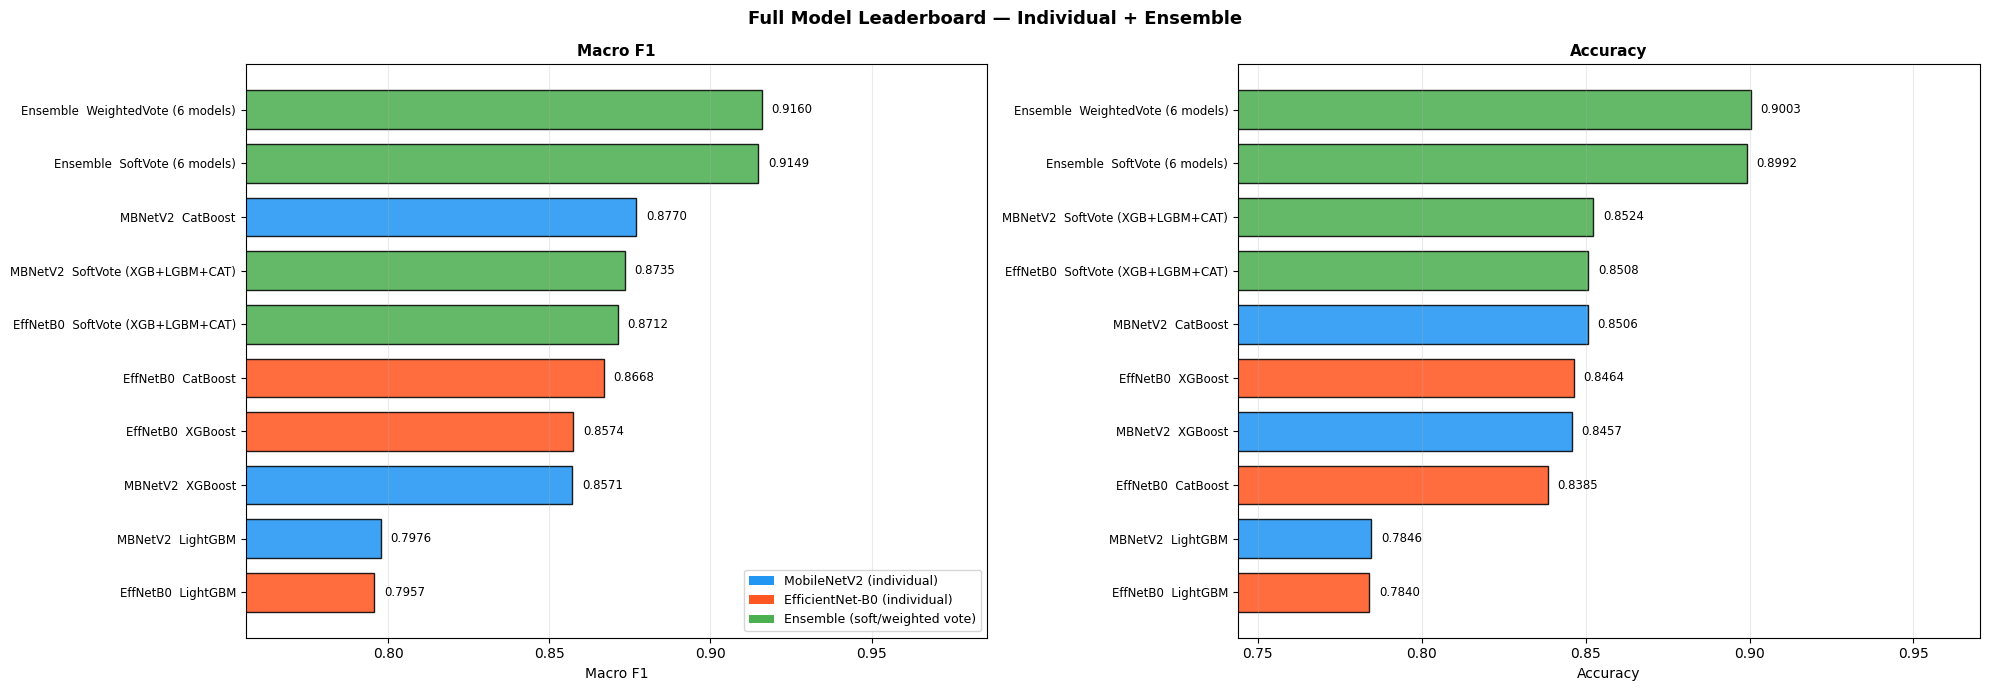

Best individual model F1 : 0.8770
  WeightedVote (6 models)       F1=0.9160  delta=+0.0390
  SoftVote (6 models)           F1=0.9149  delta=+0.0379
  SoftVote (XGB+LGBM+CAT)       F1=0.8735  delta=-0.0035
  SoftVote (XGB+LGBM+CAT)       F1=0.8712  delta=-0.0058


In [35]:
from matplotlib.patches import Patch

_ENS_NAMES = {'SoftVote (XGB+LGBM+CAT)', 'SoftVote (6 models)', 'WeightedVote (6 models)'}

def _bar_color(row):
    if row['Model'] in _ENS_NAMES:
        return '#4CAF50'
    return '#2196F3' if 'mobilenet' in row['Backbone'] else '#FF5722'

def _short_label(row):
    bb = (row['Backbone']
          .replace('mobilenet_v2', 'MBNetV2')
          .replace('efficientnet_b0', 'EffNetB0')
          .replace('ALL', 'Ensemble'))
    return f'{bb}  {row["Model"]}'

_lb = results_df_full.copy().reset_index(drop=True)
_colors  = [_bar_color(r) for _, r in _lb.iterrows()]
_labels  = [_short_label(r) for _, r in _lb.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, metric in zip(axes, ['Macro F1', 'Accuracy']):
    vals  = _lb[metric].values
    order = np.argsort(vals)          # ascending — best at top after barh
    ax.barh(range(len(order)), vals[order],
            color=[_colors[i] for i in order],
            edgecolor='black', alpha=0.87, height=0.72)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([_labels[i] for i in order], fontsize=8.5)
    ax.set_xlim(max(0, vals.min() - 0.04), min(1.0, vals.max() + 0.07))
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=11)
    for y_pos, v in enumerate(vals[order]):
        ax.text(v + 0.003, y_pos, f'{v:.4f}', va='center', fontsize=8.5)
    ax.grid(axis='x', alpha=0.25)

axes[0].legend(handles=[
    Patch(facecolor='#2196F3', label='MobileNetV2 (individual)'),
    Patch(facecolor='#FF5722', label='EfficientNet-B0 (individual)'),
    Patch(facecolor='#4CAF50', label='Ensemble (soft/weighted vote)'),
], fontsize=9, loc='lower right')

plt.suptitle('Full Model Leaderboard — Individual + Ensemble', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'leaderboard_full.png', dpi=130, bbox_inches='tight')
plt.show()

# Improvement over best individual model
_best_indiv_f1 = results_df['Macro F1'].max()
print(f'Best individual model F1 : {_best_indiv_f1:.4f}')
for _, r in _lb[_lb['Model'].isin(_ENS_NAMES)].iterrows():
    delta = r['Macro F1'] - _best_indiv_f1
    print(f'  {r["Model"]:<28}  F1={r["Macro F1"]:.4f}  delta={delta:+.4f}')

---
### 8f. ROC Curves (One-vs-Rest)

Three charts:
1. **Individual models (2×3)** — macro-avg + micro-avg ROC per model
2. **All models comparison** — macro-avg ROC for all 6 individual + 3 ensemble on one chart
3. **Per-script ROC (best model)** — shows which scripts are discriminated easiest vs hardest

> **Macro-avg AUC**: average AUC across 228 classes (treats each class equally).
> **Micro-avg AUC**: aggregate over all class predictions (weights by class frequency).
> Both use One-vs-Rest (OvR) strategy.

Computing ROC curves ...
  mobilenet_v2   xgb                 macro=0.9985  micro=0.9992
  mobilenet_v2   lgbm                macro=0.9968  micro=0.9981
  mobilenet_v2   cat                 macro=0.9987  micro=0.9993
  efficientnet_b0 xgb                 macro=0.9987  micro=0.9992
  efficientnet_b0 lgbm                macro=0.9968  micro=0.9981
  efficientnet_b0 cat                 macro=0.9986  micro=0.9992
  ALL            softvote6           macro=0.9992  micro=0.9996
  ALL            weighted6           macro=0.9992  micro=0.9996



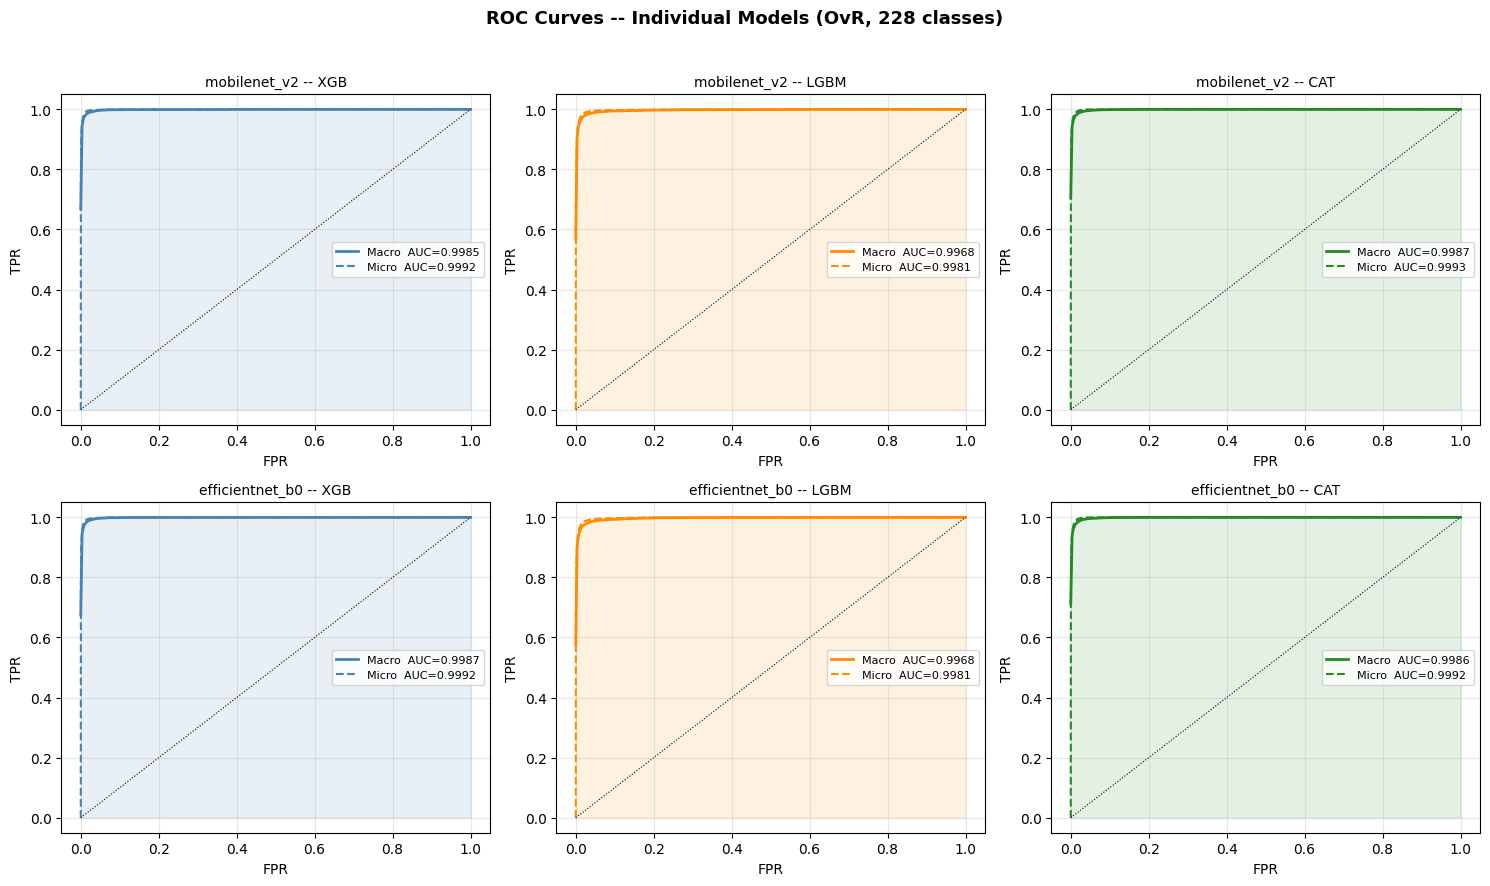

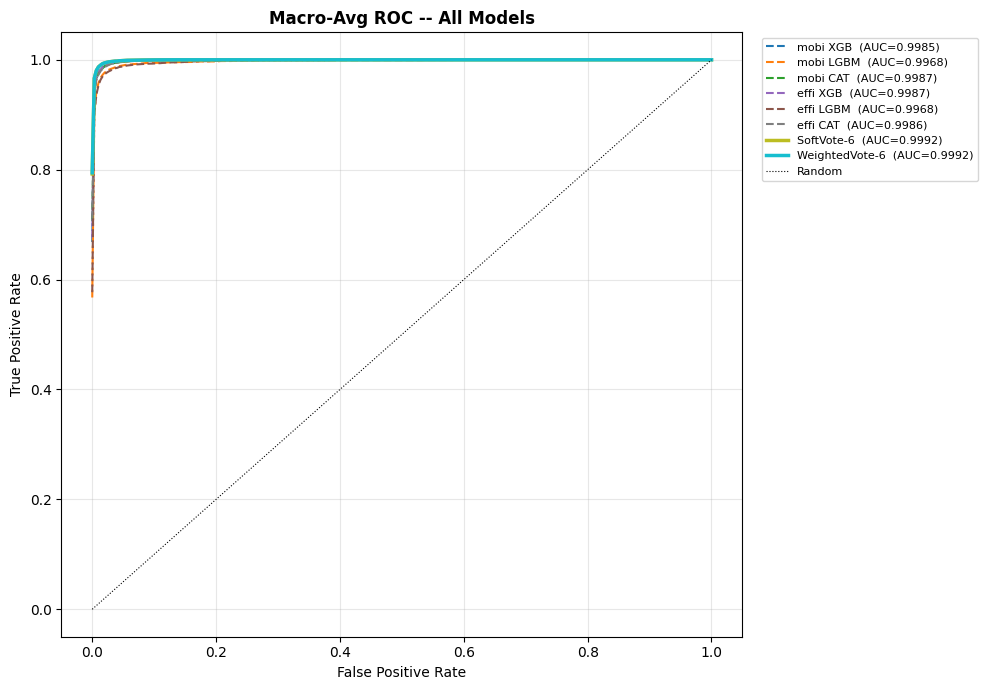

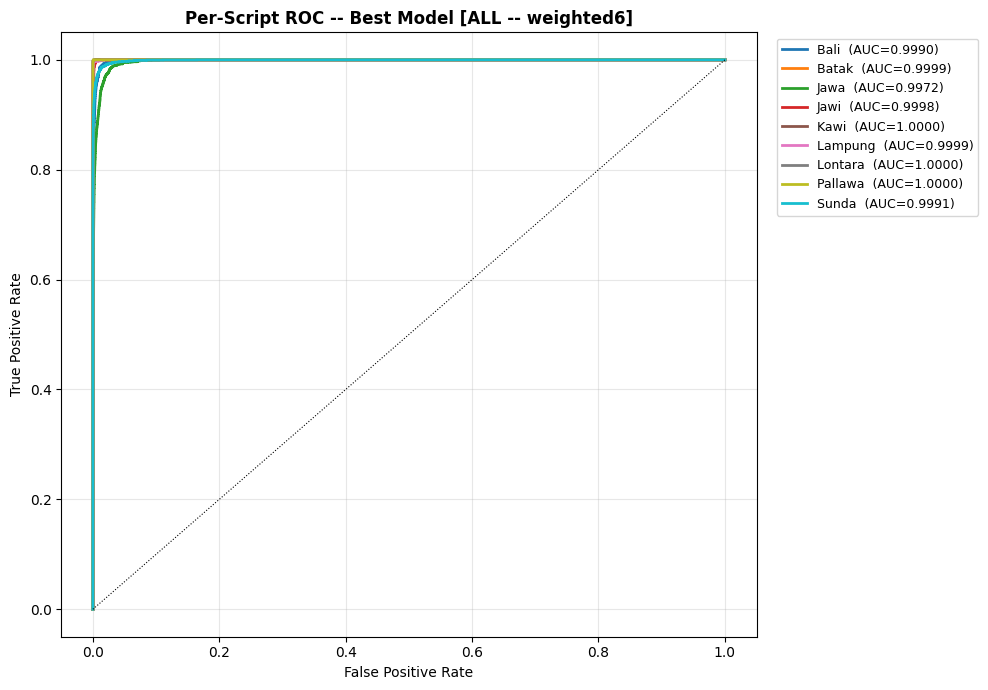


Model                              Macro AUC   Micro AUC
----------------------------------------------------------
mobi XGB                              0.9985      0.9992
mobi LGBM                             0.9968      0.9981
mobi CAT                              0.9987      0.9993
effi XGB                              0.9987      0.9992
effi LGBM                             0.9968      0.9981
effi CAT                              0.9986      0.9992
SoftVote-6                            0.9992      0.9996
WeightedVote-6                        0.9992      0.9996  <-- best


In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize ground-truth once (shared across all models)
_N_CLS    = len(CLASS_NAMES)
_CLS_IDX  = np.arange(_N_CLS)
y_bin_roc = label_binarize(y_te_ens, classes=_CLS_IDX)   # (n_test, 228)

_FPR_GRID   = np.linspace(0, 1, 300)
SCRIPT_NAMES_ROC = sorted({c.split('_')[0] for c in CLASS_NAMES})
_PALETTE_ROC = dict(zip(SCRIPT_NAMES_ROC,
                        plt.cm.tab10(np.linspace(0, 1, len(SCRIPT_NAMES_ROC)))))


def _roc_macro_micro(probas):
    """Macro-avg (fixed FPR grid) + micro-avg (flattened) OvR ROC."""
    tpr_interp = np.zeros(len(_FPR_GRID))
    for i in range(_N_CLS):
        fpr_i, tpr_i, _ = roc_curve(y_bin_roc[:, i], probas[:, i])
        tpr_interp += np.interp(_FPR_GRID, fpr_i, tpr_i)
    tpr_interp /= _N_CLS
    auc_macro = auc(_FPR_GRID, tpr_interp)

    fpr_flat, tpr_flat, _ = roc_curve(y_bin_roc.ravel(), probas.ravel())
    auc_micro = auc(fpr_flat, tpr_flat)
    return _FPR_GRID, tpr_interp, auc_macro, fpr_flat, tpr_flat, auc_micro


# Keys: individual + all-model ensembles
_INDIV_KEYS = [(bb, mk) for bb in BACKBONES for mk in ('xgb', 'lgbm', 'cat')]
_ENS_KEYS   = [('ALL', 'softvote6'), ('ALL', 'weighted6')]
_DISP_KEYS  = _INDIV_KEYS + _ENS_KEYS

_DISP_LBLS = {('ALL', 'softvote6'): 'SoftVote-6', ('ALL', 'weighted6'): 'WeightedVote-6'}
for _bb in BACKBONES:
    for _mk in ('xgb', 'lgbm', 'cat'):
        _DISP_LBLS[(_bb, _mk)] = f"{_bb[:4]} {_mk.upper()}"

ROC_DATA = {}
print('Computing ROC curves ...')
for _key in _DISP_KEYS:
    if _key not in PROBAS:
        continue
    fpr_mac, tpr_mac, auc_mac, fpr_mic, tpr_mic, auc_mic = _roc_macro_micro(PROBAS[_key])
    ROC_DATA[_key] = dict(
        fpr_mac=fpr_mac, tpr_mac=tpr_mac, auc_mac=round(auc_mac, 4),
        fpr_mic=fpr_mic, tpr_mic=tpr_mic, auc_mic=round(auc_mic, 4),
    )
    print(f'  {_key[0]:14s} {_key[1]:18s}  macro={auc_mac:.4f}  micro={auc_mic:.4f}')

print()

# ---------------------------------------------------------------
# Chart 1 — individual models 2x3 (macro + micro per subplot)
# ---------------------------------------------------------------
_LINE_COL = {'xgb': 'steelblue', 'lgbm': 'darkorange', 'cat': 'forestgreen'}
fig1, axes1 = plt.subplots(2, 3, figsize=(15, 9))
for ax, (bb, mk) in zip(axes1.flatten(), _INDIV_KEYS):
    if (bb, mk) not in ROC_DATA:
        ax.set_visible(False)
        continue
    rd  = ROC_DATA[(bb, mk)]
    col = _LINE_COL[mk]
    ax.fill_between(rd['fpr_mac'], rd['tpr_mac'], alpha=0.12, color=col)
    ax.plot(rd['fpr_mac'], rd['tpr_mac'], color=col, lw=2,
            label=f"Macro  AUC={rd['auc_mac']:.4f}")
    ax.plot(rd['fpr_mic'], rd['tpr_mic'], color=col, lw=1.5, ls='--',
            label=f"Micro  AUC={rd['auc_mic']:.4f}")
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8)
    ax.set_title(f'{bb} -- {mk.upper()}', fontsize=10)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig1.suptitle('ROC Curves -- Individual Models (OvR, 228 classes)', fontsize=13, fontweight='bold')
fig1.tight_layout(rect=[0, 0, 1, 0.96])
fig1.savefig(OUTPUT_DIR / 'roc_individual.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Chart 2 — all models macro AUC comparison
# ---------------------------------------------------------------
_cmap10 = plt.cm.tab10(np.linspace(0, 1, len(_DISP_KEYS)))
fig2, ax2 = plt.subplots(figsize=(10, 7))
for i, key in enumerate(_DISP_KEYS):
    if key not in ROC_DATA:
        continue
    rd  = ROC_DATA[key]
    lbl = _DISP_LBLS.get(key, str(key))
    lw  = 2.5 if key in _ENS_KEYS else 1.5
    ls  = '-'  if key in _ENS_KEYS else '--'
    ax2.plot(rd['fpr_mac'], rd['tpr_mac'], color=_cmap10[i], lw=lw, ls=ls,
             label=f"{lbl}  (AUC={rd['auc_mac']:.4f})")

ax2.plot([0, 1], [0, 1], 'k:', lw=0.8, label='Random')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('Macro-Avg ROC -- All Models', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / 'roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Chart 3 — per-script ROC using best model probabilities
# ---------------------------------------------------------------
_best_probas = PROBAS.get(best_pred_key)
if _best_probas is not None:
    fig3, ax3 = plt.subplots(figsize=(10, 7))
    for script in SCRIPT_NAMES_ROC:
        _cls_idx = [i for i, c in enumerate(CLASS_NAMES) if c.startswith(script + '_')]
        if not _cls_idx:
            continue
        _y_bin_s  = y_bin_roc[:, _cls_idx].ravel()
        _prob_s   = _best_probas[:, _cls_idx].ravel()
        fpr_s, tpr_s, _ = roc_curve(_y_bin_s, _prob_s)
        auc_s = auc(fpr_s, tpr_s)
        ax3.plot(fpr_s, tpr_s, color=_PALETTE_ROC[script], lw=2,
                 label=f'{script}  (AUC={auc_s:.4f})')

    ax3.plot([0, 1], [0, 1], 'k:', lw=0.8)
    ax3.set_xlabel('False Positive Rate'); ax3.set_ylabel('True Positive Rate')
    _bk_lbl = f'{best_pred_key[0]} -- {best_pred_key[1]}'
    ax3.set_title(f'Per-Script ROC -- Best Model [{_bk_lbl}]', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax3.grid(alpha=0.3)
    fig3.tight_layout()
    fig3.savefig(OUTPUT_DIR / 'roc_per_script.png', dpi=150, bbox_inches='tight')
    plt.show()

# ---------------------------------------------------------------
# AUC summary table
# ---------------------------------------------------------------
print(f"\n{'Model':<32}  {'Macro AUC':>10}  {'Micro AUC':>10}")
print('-' * 58)
for key in _DISP_KEYS:
    if key not in ROC_DATA:
        continue
    lbl    = _DISP_LBLS.get(key, str(key))
    rd     = ROC_DATA[key]
    marker = '  <-- best' if key == best_pred_key else ''
    print(f"{lbl:<32}  {rd['auc_mac']:>10.4f}  {rd['auc_mic']:>10.4f}{marker}")


## 9. Inference Demo

In [37]:
@torch.no_grad()
def predict_image(image_path, extractor, pca, model, label_enc, top_k=5):
    img = Image.open(image_path)
    if img.mode == 'RGBA':
        bg = Image.new('RGB', img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    elif img.mode == 'P':
        img = img.convert('RGBA').convert('RGB')
    else:
        img = img.convert('RGB')

    binary = binarize_pil(img.convert('L'))
    tensor = BASE_TRANSFORM(to_rgb_3ch(binary)).unsqueeze(0).to(DEVICE)

    if DEVICE.type == 'cuda':
        with torch.cuda.amp.autocast(dtype=torch.float16):
            feat = extractor(tensor).float().cpu().numpy()
    else:
        feat = extractor(tensor).cpu().numpy()
    feat_red = pca.transform(feat).astype(np.float32)

    pred_enc   = int(np.array(model.predict(feat_red)).flatten()[0])
    pred_label = label_enc.inverse_transform([pred_enc])[0]

    top_k_out = None
    if hasattr(model, 'predict_proba'):
        proba   = model.predict_proba(feat_red)[0]
        top_idx = np.argsort(proba)[::-1][:top_k]
        top_k_out = [(label_enc.inverse_transform([i])[0], round(float(proba[i]), 4))
                     for i in top_idx]
    return {
        'predicted_label': pred_label,
        'script'         : pred_label.split('_')[0],
        'character'      : '_'.join(pred_label.split('_')[1:]),
        'top_k'          : top_k_out,
    }

print('Inference function ready.')

Inference function ready.


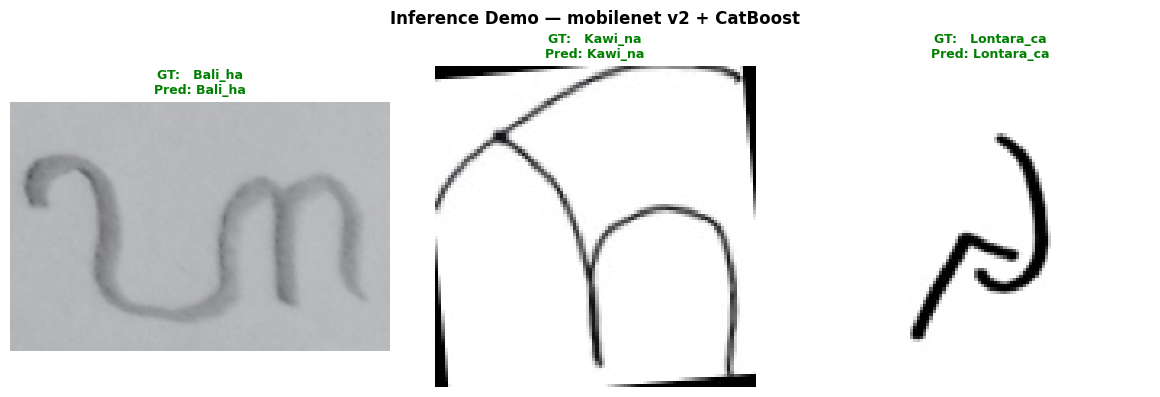


Top-5 predictions for 'Bali_ha':
  1. Bali_ha                        0.6952
  2. Bali_ta                        0.1584
  3. Bali_la                        0.0425
  4. Bali_ya                        0.0263
  5. Bali_sa                        0.0160


In [38]:
# Use best individual model for single-image inference
# (ensemble requires all 6 models; individual model is sufficient here)
_inf_bb  = best_bb if best_bb in BACKBONES else BACKBONES[0]
_inf_row = results_df[results_df['Backbone'] == _inf_bb].iloc[0]
_inf_mk  = _model_inv[_inf_row['Model']]

inf_extractor = build_extractor(_inf_bb)
inf_pca       = PCA_MODELS[_inf_bb]
inf_model     = TRAINED[(_inf_bb, _inf_mk)]

demo_scripts = ['Bali', 'Kawi', 'Lontara']
demo_rows = [df[df['script'] == s].sample(1, random_state=RANDOM_STATE + 7).iloc[0]
             for s in demo_scripts]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, row in zip(axes, demo_rows):
    result = predict_image(row['filepath'], inf_extractor, inf_pca, inf_model, le)
    ax.imshow(Image.open(row['filepath']).convert('RGB'))
    ax.axis('off')
    color = 'green' if row['label'] == result['predicted_label'] else 'red'
    ax.set_title(f"GT:   {row['label']}\nPred: {result['predicted_label']}",
                 color=color, fontsize=9, fontweight='bold')
plt.suptitle(
    f'Inference Demo — {_inf_bb.replace("_", " ")} + {MODEL_DISPLAY[_inf_mk]}',
    fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'inference_demo.png', dpi=130, bbox_inches='tight')
plt.show()

r = predict_image(demo_rows[0]['filepath'], inf_extractor, inf_pca, inf_model, le)
print(f"\nTop-5 predictions for '{demo_rows[0]['label']}':")
if r['top_k']:
    for rank, (lbl, prob) in enumerate(r['top_k'], 1):
        print(f'  {rank}. {lbl:<30} {prob:.4f}')

## 10. Final Summary

In [39]:
with open(OUTPUT_DIR / 'feature_extractor_name.txt', 'w') as f:
    f.write(best_bb)

_SEP  = '=' * 72
_SEP2 = '-' * 72
_pca_var  = {bb: round(PCA_MODELS[bb].explained_variance_ratio_.sum() * 100, 1)
             for bb in BACKBONES}
_cls_cnt  = df.groupby('label')['filepath'].count()
_imb      = round(_cls_cnt.max() / _cls_cnt.min(), 1)
_min_cls  = _cls_cnt.idxmin()
_max_cls  = _cls_cnt.idxmax()

print(_SEP)
print('  HCR NUSANTARA — FINAL EXPERIMENT REPORT')
print('  A Hybrid Cost-Sensitive Ensemble Approach for Indonesian Local')
print('  Script Handwritten Character Recognition')
print(_SEP)

# ── Dataset ───────────────────────────────────────────────────────────────────
print('\nDATASET')
print(f'  Scripts      : 9 (Bali, Batak, Jawa, Jawi, Kawi,')
print(f'                    Lampung, Lontara, Pallawa, Sunda)')
print(f'  Total images : {len(df):,}  |  Total classes : {N_CLASSES}')
print(f'  Train / Test : {len(y_train):,} / {len(y_test):,}  (stratified 80/20, seed={RANDOM_STATE})')
print(f'  Imbalance    : {_imb:.1f}x  (max: {_max_cls} / min: {_min_cls})')
print(f'  Class weights: sklearn compute_class_weight("balanced")')

# ── Pipeline ──────────────────────────────────────────────────────────────────
print('\nPIPELINE CONFIGURATION')
print(f'  Image size   : {IMG_SIZE}x{IMG_SIZE}  Grayscale -> Binarise -> 3-ch RGB')
print(f'  Backbone 1   : MobileNetV2   frozen ImageNet  '
      f'1280-d -> PCA {PCA_COMPONENTS}-d  (var {_pca_var["mobilenet_v2"]}%)')
print(f'  Backbone 2   : EfficientNet-B0 frozen ImageNet  '
      f'1280-d -> PCA {PCA_COMPONENTS}-d  (var {_pca_var["efficientnet_b0"]}%)')
print(f'  Classifiers  : XGBoost (GPU hist) + LightGBM (CPU) + CatBoost (GPU)')
print(f'  HP tuning    : Optuna TPE — {OPTUNA_TRIALS} trials/model, {int(TUNE_SUBSAMPLE*100)}% subsample')
print(f'  Estimators   : XGB/CAT = {FINAL_ESTIMATORS}  |  LGBM = {LGBM_ESTIMATORS}')
print(f'  Ensemble     : SoftVote (per-backbone) + SoftVote (all-6) + WeightedVote (all-6)')
print(f'  Device       : {DEVICE}  (GPU tree training: {USE_GPU_TREES}  '
      f'CatBoost devices: {CAT_DEVICES})')

# ── Full leaderboard ──────────────────────────────────────────────────────────
print('\nFULL LEADERBOARD (sorted by Macro F1)')
print(_SEP2)
print(results_df_full.to_string(index=True))
print(_SEP2)

# Ensemble uplift
_best_indiv_f1 = results_df['Macro F1'].max()
print(f'\nBest individual F1 : {_best_indiv_f1:.4f}')
for _, r in results_df_full[results_df_full['Model'].isin(_ENS_NAMES)].iterrows():
    delta = r['Macro F1'] - _best_indiv_f1
    print(f'  {r["Model"]:<28}  F1={r["Macro F1"]:.4f}  ({delta:+.4f} vs best individual)')

# ── Best model ────────────────────────────────────────────────────────────────
print(f'\nBEST OVERALL MODEL')
print(f'  Backbone      : {best_row["Backbone"].replace("_"," ")}')
print(f'  Model         : {best_row["Model"]}')
print(f'  Accuracy      : {best_row["Accuracy"]}')
print(f'  Macro P       : {best_row["Macro Precision"]}')
print(f'  Macro R       : {best_row["Macro Recall"]}')
print(f'  Macro F1      : {best_row["Macro F1"]}')

# ── Per-script breakdown ──────────────────────────────────────────────────────
print('\nPER-SCRIPT BREAKDOWN (best model, sorted by Macro F1)')
print(_SEP2)
print(script_df.to_string(index=True))
print(_SEP2)

# ── Class-level stats ─────────────────────────────────────────────────────────
print(f'\nCLASS-LEVEL F1  ({N_CLASSES} classes)')
print(f'  Mean   : {class_f1_s.mean():.4f}')
print(f'  Median : {class_f1_s.median():.4f}')
print(f'  Std    : {class_f1_s.std():.4f}')
print(f'  Min    : {class_f1_s.min():.4f}  ({class_f1_s.idxmin()})')
print(f'  Max    : {class_f1_s.max():.4f}  ({class_f1_s.idxmax()})')
print(f'  F1 >= 0.90 : {(class_f1_s >= 0.90).sum():>3}  '
      f'({(class_f1_s >= 0.90).mean()*100:.1f}%)')
print(f'  F1 >= 0.80 : {(class_f1_s >= 0.80).sum():>3}  '
      f'({(class_f1_s >= 0.80).mean()*100:.1f}%)')
print(f'  F1 <  0.50 : {(class_f1_s <  0.50).sum():>3}  '
      f'({(class_f1_s < 0.50).mean()*100:.1f}%)')
print(f'  Top-3 confused pairs:')
for _, row in confused_df.head(3).iterrows():
    print(f'    {row["True"]:<30} -> {row["Predicted"]:<30}  '
          f'count={row["Count"]}  rate={row["Error Rate"]:.3f}')

# ── Saved artifacts ───────────────────────────────────────────────────────────
print('\nSAVED ARTIFACTS')
for fp in sorted(OUTPUT_DIR.iterdir()):
    size_kb = fp.stat().st_size // 1024
    print(f'  {fp.name:<48} {size_kb:>6} KB')

print()
print(_SEP)

# ── Deployment: inference_config.json ────────────────────────────────────────
import json as _json

_ens_label_to_key = {
    'SoftVote (XGB+LGBM+CAT)': 'softvote',
    'SoftVote (6 models)'     : 'softvote6',
    'WeightedVote (6 models)' : 'weighted6',
}
_best_is_ensemble    = best_row['Model'] in _ens_label_to_key
_indiv_backbone      = best_bb if not _best_is_ensemble else None
_indiv_model_key     = _model_inv.get(best_row['Model']) if not _best_is_ensemble else None

_inference_cfg = {
    'best_backbone'        : best_row['Backbone'],
    'best_model'           : best_row['Model'],
    'best_pred_key'        : list(best_pred_key),
    'is_ensemble'          : _best_is_ensemble,
    'ensemble_backbones'   : BACKBONES if _best_is_ensemble else None,
    'individual_backbone'  : _indiv_backbone,
    'individual_model_key' : _indiv_model_key,
    'macro_f1'             : float(best_row['Macro F1']),
    'accuracy'             : float(best_row['Accuracy']),
    'n_classes'            : int(N_CLASSES),
    'img_size'             : int(IMG_SIZE),
    'pca_components'       : int(PCA_COMPONENTS),
    'backbone_feat_dim'    : 1280,
    'backbones'            : BACKBONES,
    'class_names_file'     : 'class_names.npy',
    'label_encoder_file'   : 'label_encoder.pkl',
    'pca_dir'              : str(FEATURES_DIR),
    'models_dir'           : str(OUTPUT_DIR),
}
with open(OUTPUT_DIR / 'inference_config.json', 'w') as _f:
    _json.dump(_inference_cfg, _f, indent=2)

print(f'\nDeployment config saved -> {OUTPUT_DIR / "inference_config.json"}')


  HCR NUSANTARA — FINAL EXPERIMENT REPORT
  A Hybrid Cost-Sensitive Ensemble Approach for Indonesian Local
  Script Handwritten Character Recognition

DATASET
  Scripts      : 9 (Bali, Batak, Jawa, Jawi, Kawi,
                    Lampung, Lontara, Pallawa, Sunda)
  Total images : 55,713  |  Total classes : 228
  Train / Test : 44,570 / 11,143  (stratified 80/20, seed=42)
  Imbalance    : 14.5x  (max: Sunda_u / min: Jawi_alif)
  Class weights: sklearn compute_class_weight("balanced")

PIPELINE CONFIGURATION
  Image size   : 224x224  Grayscale -> Binarise -> 3-ch RGB
  Backbone 1   : MobileNetV2   frozen ImageNet  1280-d -> PCA 256-d  (var 95.9000015258789%)
  Backbone 2   : EfficientNet-B0 frozen ImageNet  1280-d -> PCA 256-d  (var 94.0999984741211%)
  Classifiers  : XGBoost (GPU hist) + LightGBM (CPU) + CatBoost (GPU)
  HP tuning    : Optuna TPE — 20 trials/model, 30% subsample
  Estimators   : XGB/CAT = 500  |  LGBM = 100
  Ensemble     : SoftVote (per-backbone) + SoftVote (all-6) + W

## 11. Deployment

All artefacts required to run the Streamlit inference app are saved in `OUTPUT_DIR/models/`.

### Artifact Map

| File | Description |
|------|-------------|
| `inference_config.json` | Best model config — backbone, model key, is_ensemble flag |
| `class_names.npy` | Ordered array of 228 class labels |
| `label_encoder.pkl` | sklearn LabelEncoder for int ↔ label conversion |
| `{bb}_xgb.pkl` | XGBoost classifier (2 backbones) |
| `{bb}_lgbm.pkl` | LightGBM classifier (2 backbones) |
| `{bb}_catboost.cbm` | CatBoost classifier (2 backbones) |
| `features/pca_{bb}.pkl` | PCA 1280→256 transform (2 backbones) |

CNN backbone weights are loaded at runtime from torchvision (standard ImageNet weights — no separate file needed).

### Launching the app (local)
```bash
pip install streamlit
streamlit run app.py
```


In [ ]:
# ── Deployment readiness check ───────────────────────────────────────────────
import json as _json

_cfg_path = OUTPUT_DIR / 'inference_config.json'
assert _cfg_path.exists(), 'inference_config.json missing — re-run Cell 56'

with open(_cfg_path) as _f:
    _cfg = _json.load(_f)

_REQUIRED_FILES = [
    OUTPUT_DIR / 'class_names.npy',
    OUTPUT_DIR / 'label_encoder.pkl',
]
for _bb in _cfg['backbones']:
    _REQUIRED_FILES += [
        OUTPUT_DIR / f'{_bb}_xgb.pkl',
        OUTPUT_DIR / f'{_bb}_lgbm.pkl',
        OUTPUT_DIR / f'{_bb}_catboost.cbm',
        FEATURES_DIR / f'pca_{_bb}.pkl',
    ]

_missing = [str(p) for p in _REQUIRED_FILES if not p.exists()]

print('Deployment Readiness Check')
print('=' * 50)
print(f'  Best model      : [{_cfg["best_backbone"]}] {_cfg["best_model"]}')
print(f'  Macro F1        : {_cfg["macro_f1"]:.4f}')
print(f'  Accuracy        : {_cfg["accuracy"]:.4f}')
print(f'  Is ensemble     : {_cfg["is_ensemble"]}')
print(f'  Classes         : {_cfg["n_classes"]}')
print(f'  Image size      : {_cfg["img_size"]}x{_cfg["img_size"]}')
print(f'  PCA components  : {_cfg["pca_components"]}')
print()
if _missing:
    print(f'  MISSING ({len(_missing)} files):')
    for _m in _missing:
        print(f'    ✗ {_m}')
else:
    print(f'  All {len(_REQUIRED_FILES)} required files present.')
    print('  Ready for app.py deployment.')

# Print artifact list with sizes
print()
print('Saved artifacts:')
for _p in sorted(list(OUTPUT_DIR.iterdir()) + list(FEATURES_DIR.iterdir())):
    if _p.is_file():
        _sz = _p.stat().st_size
        _unit = 'MB' if _sz > 1_000_000 else 'KB'
        _val  = _sz / 1_000_000 if _sz > 1_000_000 else _sz / 1_000
        print(f'  {str(_p.relative_to(WORK_DIR)):<55} {_val:6.1f} {_unit}')
